In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 1: ORTAM KURULUMU VE H100 YAPILANDIRMASI
# =============================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import mixed_precision
from google.colab import drive

print("=" * 65)
print("   FEDERE MHA-LSTM EĞİTİMİ — H100 ORTAM BAŞLATILIYOR")
print("=" * 65)

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
print("✅ Google Drive bağlandı.")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Aktif: {len(gpus)} adet")
        for i, gpu in enumerate(gpus):
            details = tf.config.experimental.get_device_details(gpu)
            print(f"   -> GPU {i}: {details.get('device_name', 'Bilinmiyor')}")
    except RuntimeError as e:
        print(f"⚠️ GPU Ayar Hatası: {e}")
else:
    print("⚠️ GPU Bulunamadı!")

mixed_precision.set_global_policy('mixed_bfloat16')
print(f"✅ Mixed Precision: {mixed_precision.global_policy().name}")

tf.config.optimizer.set_jit(True)
print("✅ XLA JIT Derleme: AKTİF")

# -----------------------------------------------------------------------------
# GLOBAL SABİTLER  ← FAZ 1 DEĞİŞİKLİKLERİ BURADA
# -----------------------------------------------------------------------------
ROOT_PATH      = '/content/drive/MyDrive/wifi_mqtt'

# Veri (değişmedi)
TIME_STEPS     = 20
TEST_SIZE      = 0.20
PCA_VARIANCE   = 0.95
SEED           = 42

# Federe Eğitim  ← DEĞİŞTİ
ROUNDS         = 50       # 10 → 50
LOCAL_EPOCHS   = 8        # 5  → 8
BATCH_SIZE     = 8192     # 4096 → 8192  (H100 80GB rahatlıkla kaldırır)
LEARNING_RATE  = 0.001    # 0.0003 → 0.001 (cosine decay başlangıcı)

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("\n📋 FAZ 1 — GÜNCEL GLOBAL SABİTLER:")
print(f"   ROOT_PATH      : {ROOT_PATH}")
print(f"   TIME_STEPS     : {TIME_STEPS}")
print(f"   PCA_VARIANCE   : %{PCA_VARIANCE*100:.0f}")
print(f"   BATCH_SIZE     : {BATCH_SIZE}  ← H100 optimize")
print(f"   FEDERE ROUNDS  : {ROUNDS}      ← 10'dan 50'ye")
print(f"   LOCAL_EPOCHS   : {LOCAL_EPOCHS}         ← 5'ten 8'e")
print(f"   LEARNING_RATE  : {LEARNING_RATE}   ← cosine decay ile kullanılacak")

print(f"\n✅ TensorFlow : {tf.__version__}")
print(f"✅ NumPy      : {np.__version__}")
print("\n" + "=" * 65)
print("   ORTAM HAZIR — HÜCRE 2'YE GEÇEBİLİRSİNİZ")
print("=" * 65)

   FEDERE MHA-LSTM EĞİTİMİ — H100 ORTAM BAŞLATILIYOR
Mounted at /content/drive
✅ Google Drive bağlandı.
✅ GPU Aktif: 1 adet
   -> GPU 0: NVIDIA H100 80GB HBM3
✅ Mixed Precision: mixed_bfloat16
✅ XLA JIT Derleme: AKTİF

📋 FAZ 1 — GÜNCEL GLOBAL SABİTLER:
   ROOT_PATH      : /content/drive/MyDrive/wifi_mqtt
   TIME_STEPS     : 20
   PCA_VARIANCE   : %95
   BATCH_SIZE     : 8192  ← H100 optimize
   FEDERE ROUNDS  : 50      ← 10'dan 50'ye
   LOCAL_EPOCHS   : 8         ← 5'ten 8'e
   LEARNING_RATE  : 0.001   ← cosine decay ile kullanılacak

✅ TensorFlow : 2.19.0
✅ NumPy      : 2.0.2

   ORTAM HAZIR — HÜCRE 2'YE GEÇEBİLİRSİNİZ


   VERİ HAZIRLAMA AŞAMASI BAŞLATILIYOR

📂 Normal (Profiling) dosyaları taranıyor...
   -> Bulunan toplam dosya: 42

⏳ Dosyalar yükleniyor...
   -> Ham veri boyutu: (389956, 45)

🧹 Veri temizleniyor...
   -> Silinen sabit kolonlar (5 adet): ['Drate', 'Telnet', 'SMTP', 'SSH', 'IRC']
   -> Temizleme sonrası boyut: (389956, 40)
   -> Kullanılacak özellik sayısı: 40

⚖️ Global StandardScaler uygulanıyor...
   -> Global scaler kaydedildi: federe_mha_scaler.pkl
   -> Scaler feature sayısı   : 40

🔬 PCA Varyans Analizi yapılıyor (Hedef: %95)...
   -> %95 varyans için gereken bileşen sayısı: 20
   -> Eski sabit değer (45) yerine 20 bileşen kullanılacak


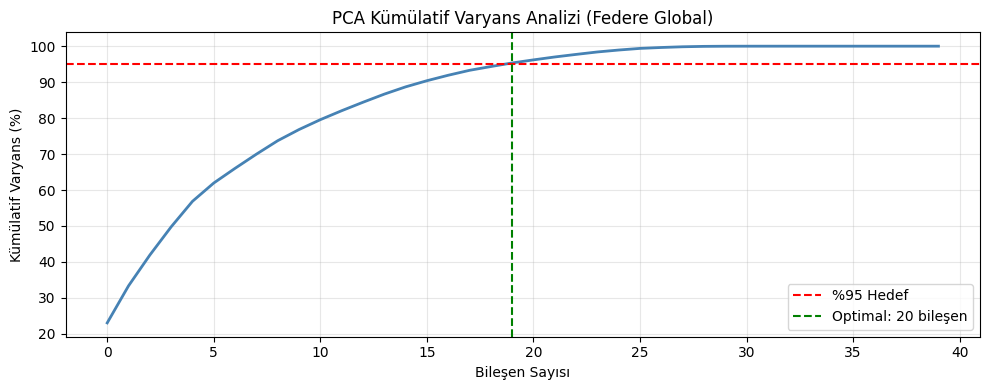

   -> Global PCA kaydedildi: federe_mha_pca.pkl

📊 ÖZET:
   -> Toplam veri boyutu    : (389956, 40)
   -> Açıklanan varyans     : %95.34
   -> PCA_COMPONENTS        : 20
   -> FEATURE_COLUMNS sayısı: 40

   HÜCRE 2 TAMAMLANDI — HÜCRE 3'E GEÇEBİLİRSİNİZ


In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 2: VERİ YÜKLEME, TEMİZLEME, SCALING VE OTOMATİK PCA
# =============================================================================
# Merkezi notebook'taki pipeline'ın birebir aynısı.
# PCA burada FIT edilir → sonraki hücrelerde client'lara TRANSFORM uygulanır.
# =============================================================================

import os
import gc
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("=" * 65)
print("   VERİ HAZIRLAMA AŞAMASI BAŞLATILIYOR")
print("=" * 65)

# -----------------------------------------------------------------------------
# 1. NORMAL (PROFİLİNG) DOSYALARINI TARA
# -----------------------------------------------------------------------------
print("\n📂 Normal (Profiling) dosyaları taranıyor...")
all_benign_files = []
for root, dirs, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".csv") and 'profiling' in root.lower():
            all_benign_files.append(os.path.join(root, file))

print(f"   -> Bulunan toplam dosya: {len(all_benign_files)}")

if not all_benign_files:
    raise ValueError("❌ Hiç profiling dosyası bulunamadı! ROOT_PATH'i kontrol et.")

# -----------------------------------------------------------------------------
# 2. TÜM DOSYALARI YÜKLE VE BİRLEŞTİR (Global PCA için tam veri gerekli)
# -----------------------------------------------------------------------------
print("\n⏳ Dosyalar yükleniyor...")
dfs = []
for f in all_benign_files:
    try:
        df = pd.read_csv(f)
        df = df.select_dtypes(include=[np.number])
        df = df.astype('float32')
        dfs.append(df)
    except Exception as e:
        print(f"   ⚠️ Atlandı ({os.path.basename(f)}): {e}")

df_full = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

print(f"   -> Ham veri boyutu: {df_full.shape}")

# -----------------------------------------------------------------------------
# 3. TEMİZLEME
# -----------------------------------------------------------------------------
print("\n🧹 Veri temizleniyor...")

df_full.replace([np.inf, -np.inf], np.nan, inplace=True)
df_full.dropna(inplace=True)

# Sıfır varyanslı (sabit) kolonları sil
varyanslar = df_full.var()
sifir_varyansli_kolonlar = varyanslar[varyanslar == 0].index.tolist()
df_full.drop(columns=sifir_varyansli_kolonlar, inplace=True)

print(f"   -> Silinen sabit kolonlar ({len(sifir_varyansli_kolonlar)} adet): {sifir_varyansli_kolonlar}")
print(f"   -> Temizleme sonrası boyut: {df_full.shape}")

# Kolon isimlerini global olarak sakla (test aşamasında alignment için)
FEATURE_COLUMNS = df_full.columns.tolist()
print(f"   -> Kullanılacak özellik sayısı: {len(FEATURE_COLUMNS)}")

# -----------------------------------------------------------------------------
# 4. GLOBAL STANDARD SCALING
# Federe sistemde scaler GLOBAL olmalı — tüm veriye fit edilir,
# her client kendi verisine sadece TRANSFORM uygular.
# -----------------------------------------------------------------------------
print("\n⚖️ Global StandardScaler uygulanıyor...")
scaler = StandardScaler()
scaled_full = scaler.fit_transform(df_full)

joblib.dump(scaler, 'federe_mha_scaler.pkl')
print(f"   -> Global scaler kaydedildi: federe_mha_scaler.pkl")
print(f"   -> Scaler feature sayısı   : {len(scaler.feature_names_in_)}")

# -----------------------------------------------------------------------------
# 5. OTOMATİK PCA — %95 VARYANS HEDEFİ
# Aynı şekilde PCA da GLOBAL — tüm veriye fit, client'lara transform
# -----------------------------------------------------------------------------
print(f"\n🔬 PCA Varyans Analizi yapılıyor (Hedef: %{PCA_VARIANCE*100:.0f})...")

pca_full = PCA(random_state=SEED)
pca_full.fit(scaled_full)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_optimal = int(np.argmax(cumulative_variance >= PCA_VARIANCE) + 1)

print(f"   -> %{PCA_VARIANCE*100:.0f} varyans için gereken bileşen sayısı: {n_components_optimal}")
print(f"   -> Eski sabit değer (45) yerine {n_components_optimal} bileşen kullanılacak")

# Varyans grafiği
plt.figure(figsize=(10, 4))
plt.plot(cumulative_variance * 100, linewidth=2, color='steelblue')
plt.axhline(y=95, color='red', linestyle='--', label='%95 Hedef')
plt.axvline(x=n_components_optimal - 1, color='green', linestyle='--',
            label=f'Optimal: {n_components_optimal} bileşen')
plt.xlabel('Bileşen Sayısı')
plt.ylabel('Kümülatif Varyans (%)')
plt.title('PCA Kümülatif Varyans Analizi (Federe Global)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optimal bileşen sayısıyla gerçek PCA
pca = PCA(n_components=n_components_optimal, random_state=SEED)
pca.fit(scaled_full)

joblib.dump(pca, 'federe_mha_pca.pkl')
print(f"   -> Global PCA kaydedildi: federe_mha_pca.pkl")

# Global değişkene aktar (sonraki hücrelerde kullanılacak)
PCA_COMPONENTS = n_components_optimal

# Temizlik
del scaled_full, pca_full
gc.collect()

# -----------------------------------------------------------------------------
# 6. CLIENT'LARA AYRILACAK HAM DATAFRAME'İ SAKLA
# (Sonraki hücrede client bazlı bölme yapacağız)
# df_full burada tutulur, hücre 3'te bölünür
# -----------------------------------------------------------------------------
print(f"\n📊 ÖZET:")
print(f"   -> Toplam veri boyutu    : {df_full.shape}")
print(f"   -> Açıklanan varyans     : %{cumulative_variance[n_components_optimal-1]*100:.2f}")
print(f"   -> PCA_COMPONENTS        : {PCA_COMPONENTS}")
print(f"   -> FEATURE_COLUMNS sayısı: {len(FEATURE_COLUMNS)}")

print("\n" + "=" * 65)
print("   HÜCRE 2 TAMAMLANDI — HÜCRE 3'E GEÇEBİLİRSİNİZ")
print("=" * 65)

In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 3: CLIENT BAZLI VERİ BÖLME, SEQUENCE VE tf.data
# =============================================================================
# df_full (hücre 2'den) → 3 client'a bölünür
# Her client için:
#   1. Scaler transform  (fit hücre 2'de yapıldı)
#   2. PCA transform     (fit hücre 2'de yapıldı)
#   3. Sequence oluştur  (stride trick — sıfır kopya, hızlı)
#   4. Train/Val split   (kronolojik — zaman sızıntısı yok)
#   5. tf.data pipeline  (cache + prefetch — H100 boşta kalmaz)
# =============================================================================

import gc
import numpy as np
import tensorflow as tf

print("=" * 65)
print("   CLIENT BAZLI VERİ HAZIRLAMA BAŞLATILIYOR")
print("=" * 65)

# -----------------------------------------------------------------------------
# 1. CLIENT AYIRMA STRATEJİSİ
# Federe notebook'taki mantığı koruyoruz:
#   Client 1 (WiFi)  → MQTT içermeyen dosyalar
#   Client 2 (MQTT)  → MQTT içeren dosyalar
#   Client 3 (Mixed) → Her ikisinin son %20'sinin karışımı
# ANCAK artık ham CSV yerine df_full üzerinden çalışıyoruz.
# Dosya bazlı indeks takibi yapacağız.
# -----------------------------------------------------------------------------
print("\n📂 Client dosya listesi oluşturuluyor...")

wifi_files  = []
mqtt_files  = []

for f in all_benign_files:
    fname = os.path.basename(f).lower()
    if 'mqtt' in fname:
        mqtt_files.append(f)
    else:
        wifi_files.append(f)

# MQTT yoksa yarı yarıya böl
if len(mqtt_files) < 2:
    print("   ⚠️  İsimden MQTT ayrımı yapılamadı → dosyalar rastgele bölünüyor...")
    mid = len(all_benign_files) // 2
    wifi_files  = all_benign_files[:mid]
    mqtt_files  = all_benign_files[mid:]

print(f"   -> Client 1 (WiFi)  dosya sayısı: {len(wifi_files)}")
print(f"   -> Client 2 (MQTT)  dosya sayısı: {len(mqtt_files)}")

# -----------------------------------------------------------------------------
# 2. CLIENT BAZLI DATAFRAME OLUŞTURMA
# df_full zaten bellekte; dosya sırasına göre satırları atamak yerine
# dosyaları tekrar okuyoruz — böylece client verisi gerçekten ayrı kalır.
# -----------------------------------------------------------------------------
print("\n⏳ Client dataframe'leri oluşturuluyor...")

def load_client_df(file_list, client_name):
    dfs = []
    for f in file_list:
        try:
            df = pd.read_csv(f)
            df = df.select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)
            # Kolon eşitleme — scaler'ın beklediği kolonlar
            for col in set(FEATURE_COLUMNS) - set(df.columns):
                df[col] = 0.0
            df = df[FEATURE_COLUMNS]
            dfs.append(df)
        except Exception as e:
            print(f"   ⚠️ {client_name} - Atlandı: {os.path.basename(f)}: {e}")
    result = pd.concat(dfs, ignore_index=True)
    print(f"   -> {client_name}: {result.shape}")
    return result

df_wifi = load_client_df(wifi_files,  "Client 1 (WiFi)")
df_mqtt = load_client_df(mqtt_files,  "Client 2 (MQTT)")

# Client 3: WiFi'nin son %20'si + MQTT'nin son %20'si
cut_wifi = int(len(df_wifi) * 0.80)
cut_mqtt = int(len(df_mqtt) * 0.80)
df_mixed = pd.concat([df_wifi.iloc[cut_wifi:], df_mqtt.iloc[cut_mqtt:]], ignore_index=True)
print(f"   -> Client 3 (Mixed): {df_mixed.shape}")

# -----------------------------------------------------------------------------
# 3. SEQUENCE OLUŞTURMA FONKSİYONU (stride trick — merkezi notebook'tan)
# -----------------------------------------------------------------------------
def create_sequences_fast(data, time_steps):
    """
    np.lib.stride_tricks ile sıfır kopya (zero-copy) sequence oluşturur.
    Klasik for döngüsüne göre ~10x daha hızlı ve RAM dostu.
    """
    n_samples  = data.shape[0] - time_steps
    n_features = data.shape[1]
    shape   = (n_samples, time_steps, n_features)
    strides = (data.strides[0], data.strides[0], data.strides[1])
    seq = np.lib.stride_tricks.as_strided(data, shape=shape, strides=strides)
    return np.array(seq, dtype=np.float32)  # view'dan güvenli kopyaya al

# -----------------------------------------------------------------------------
# 4. PIPELINE UYGULAMA: Scale → PCA → Sequence
# -----------------------------------------------------------------------------
print(f"\n⚡ Scale → PCA → Sequence pipeline uygulanıyor...")

def apply_pipeline(df, client_name):
    scaled    = scaler.transform(df).astype(np.float32)
    pca_trans = pca.transform(scaled).astype(np.float32)
    sequences = create_sequences_fast(pca_trans, TIME_STEPS)
    print(f"   -> {client_name}: sequence shape = {sequences.shape}  "
          f"| RAM = {sequences.nbytes / 1e6:.1f} MB")
    return sequences

X_client1 = apply_pipeline(df_wifi,  "Client 1 (WiFi)")
X_client2 = apply_pipeline(df_mqtt,  "Client 2 (MQTT)")
X_client3 = apply_pipeline(df_mixed, "Client 3 (Mixed)")

# Ham dataframe'leri temizle
del df_wifi, df_mqtt, df_mixed, df_full
gc.collect()

# -----------------------------------------------------------------------------
# 5. KRONOLOJİK TRAIN / VAL SPLIT (zaman sızıntısı yok)
# -----------------------------------------------------------------------------
print(f"\n✂️  Kronolojik Train/Val bölmesi yapılıyor (%80/%20)...")

def split_client(X, name):
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_tr  = X[:split_idx]
    X_val = X[split_idx:]
    print(f"   -> {name}: train={X_tr.shape} | val={X_val.shape}")
    return X_tr, X_val

X_tr1, X_val1 = split_client(X_client1, "Client 1 (WiFi)")
X_tr2, X_val2 = split_client(X_client2, "Client 2 (MQTT)")
X_tr3, X_val3 = split_client(X_client3, "Client 3 (Mixed)")

# -----------------------------------------------------------------------------
# 6. tf.data PIPELINE — H100 İÇİN (cache + shuffle + prefetch)
# -----------------------------------------------------------------------------
print(f"\n⚡ tf.data pipeline kuruluyor (batch={BATCH_SIZE})...")

AUTOTUNE = tf.data.AUTOTUNE

def make_tf_datasets(X_tr, X_val, client_name):
    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, X_tr))
        .cache()
        .shuffle(buffer_size=15000, seed=SEED)
        .batch(BATCH_SIZE, drop_remainder=True)   # sabit batch → XLA dostu
        .prefetch(AUTOTUNE)
    )
    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, X_val))
        .cache()
        .batch(BATCH_SIZE, drop_remainder=False)
        .prefetch(AUTOTUNE)
    )
    print(f"   -> {client_name}: "
          f"train_batches={len(train_ds)} | val_batches={len(val_ds)}")
    return train_ds, val_ds

train_ds1, val_ds1 = make_tf_datasets(X_tr1, X_val1, "Client 1 (WiFi)")
train_ds2, val_ds2 = make_tf_datasets(X_tr2, X_val2, "Client 2 (MQTT)")
train_ds3, val_ds3 = make_tf_datasets(X_tr3, X_val3, "Client 3 (Mixed)")

# Client dataseti listesi — federe döngüde kullanılacak
CLIENT_DATASETS = [
    {"name": "WiFi",  "train": train_ds1, "val": val_ds1,
     "n_train": len(X_tr1), "n_val": len(X_val1)},
    {"name": "MQTT",  "train": train_ds2, "val": val_ds2,
     "n_train": len(X_tr2), "n_val": len(X_val2)},
    {"name": "Mixed", "train": train_ds3, "val": val_ds3,
     "n_train": len(X_tr3), "n_val": len(X_val3)},
]

# Örnek batch kontrolü
for batch_x, batch_y in train_ds1.take(1):
    print(f"\n✅ Örnek batch kontrolü (Client 1):")
    print(f"   -> batch_x shape : {batch_x.shape}")
    print(f"   -> dtype         : {batch_x.dtype}")

print("\n" + "=" * 65)
print("   HÜCRE 3 TAMAMLANDI — HÜCRE 4'E GEÇEBİLİRSİNİZ")
print("=" * 65)

   CLIENT BAZLI VERİ HAZIRLAMA BAŞLATILIYOR

📂 Client dosya listesi oluşturuluyor...
   ⚠️  İsimden MQTT ayrımı yapılamadı → dosyalar rastgele bölünüyor...
   -> Client 1 (WiFi)  dosya sayısı: 21
   -> Client 2 (MQTT)  dosya sayısı: 21

⏳ Client dataframe'leri oluşturuluyor...
   -> Client 1 (WiFi): (131133, 40)
   -> Client 2 (MQTT): (258823, 40)
   -> Client 3 (Mixed): (77992, 40)

⚡ Scale → PCA → Sequence pipeline uygulanıyor...
   -> Client 1 (WiFi): sequence shape = (131113, 20, 20)  | RAM = 209.8 MB
   -> Client 2 (MQTT): sequence shape = (258803, 20, 20)  | RAM = 414.1 MB
   -> Client 3 (Mixed): sequence shape = (77972, 20, 20)  | RAM = 124.8 MB

✂️  Kronolojik Train/Val bölmesi yapılıyor (%80/%20)...
   -> Client 1 (WiFi): train=(104890, 20, 20) | val=(26223, 20, 20)
   -> Client 2 (MQTT): train=(207042, 20, 20) | val=(51761, 20, 20)
   -> Client 3 (Mixed): train=(62377, 20, 20) | val=(15595, 20, 20)

⚡ tf.data pipeline kuruluyor (batch=8192)...
   -> Client 1 (WiFi): train_bat

In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 4: MODEL MİMARİSİ (NaN-SAFE, H100 UYUMLU)
# =============================================================================
# Merkezi notebook'taki build_model fonksiyonunun birebir aynısı.
# Tek fark: input shape artık (TIME_STEPS=20, PCA_COMPONENTS=20)
#
# MİMARİ ÖZET:
#   ENCODER:
#     Conv1D(64)                    → lokal örüntü (burst/spike) çıkarımı
#     BiLSTM(128)                   → zamansal bağımlılık (iki yön)
#     TransformerBlock(256, 4head)  → global dikkat mekanizması
#     LSTM(64) + LayerNorm          → bottleneck (sıkıştırma)
#     TransformerBlock(64,  4head)  → bottleneck dikkat
#   DECODER:
#     LSTM(128)
#     TransformerBlock(128, 4head)
#     LSTM(256)
#     TimeDistributed Dense(20)     → PCA uzayında rekonstrüksiyon
#
# LOSS: 0.6*MAE + 0.4*MSE (float32 cast ile NaN-safe)
# OPT : Adam(lr=0.0003, clipvalue=0.5, epsilon=1e-7)
# =============================================================================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, Add, TimeDistributed, Conv1D,
    Bidirectional, Lambda
)
from tensorflow.keras.optimizers import Adam
import gc

print("=" * 65)
print("   MHA-LSTM MODEL MİMARİSİ KURULUYOR (NaN-SAFE)")
print("=" * 65)

# Önceki oturumdan kalan varsa temizle
tf.keras.backend.clear_session()
gc.collect()

# -----------------------------------------------------------------------------
# 1. NaN-SAFE COMBINED LOSS (merkezi notebook'tan — float32 cast zorunlu)
# BF16 mixed precision ile NaN üretme riski var, bu yüzden her iki tensör
# loss içinde float32'ye cast ediliyor.
# -----------------------------------------------------------------------------
def combined_reconstruction_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return 0.6 * mae + 0.4 * mse

# -----------------------------------------------------------------------------
# 2. TRANSFORMER ENCODER BLOĞU
# Pre-LayerNorm yapısı (Post-LayerNorm'dan daha stabil eğitim)
# gelu yerine relu — BF16'da NaN riski daha az
# -----------------------------------------------------------------------------
def transformer_encoder_block(x, embed_dim, num_heads, ff_dim,
                               dropout_rate, name_prefix=""):
    # Multi-Head Self-Attention
    attn_input  = LayerNormalization(epsilon=1e-5,
                      name=f"{name_prefix}_ln1")(x)
    attn_output = MultiHeadAttention(
                      num_heads=num_heads,
                      key_dim=embed_dim // num_heads,
                      dropout=dropout_rate,
                      name=f"{name_prefix}_mha"
                  )(attn_input, attn_input)
    x = Add(name=f"{name_prefix}_add1")([x, attn_output])

    # Feed-Forward
    ff_input  = LayerNormalization(epsilon=1e-5,
                    name=f"{name_prefix}_ln2")(x)
    ff_output = Dense(ff_dim, activation='relu',
                    name=f"{name_prefix}_ff1")(ff_input)   # relu → NaN-safe
    ff_output = Dropout(dropout_rate,
                    name=f"{name_prefix}_drop")(ff_output)
    ff_output = Dense(embed_dim,
                    name=f"{name_prefix}_ff2")(ff_output)
    x = Add(name=f"{name_prefix}_add2")([x, ff_output])

    return x

# -----------------------------------------------------------------------------
# 3. MODEL MİMARİSİ
# input_shape = (TIME_STEPS, PCA_COMPONENTS) = (20, 20)
# -----------------------------------------------------------------------------
def build_model(time_steps, pca_components):

    inputs = Input(shape=(time_steps, pca_components),
                   dtype='float32', name='input')

    # =========================================================================
    # ENCODER
    # =========================================================================

    # Conv1D — lokal örüntü çıkarımı (burst/spike tespiti)
    x = Conv1D(64, kernel_size=3, padding='same',
               activation='relu', name='conv_local')(inputs)

    # BiLSTM — iki yönlü zamansal bağımlılık
    x = Bidirectional(
            LSTM(128, return_sequences=True, activation='tanh',
                 recurrent_dropout=0.0,               # NaN riski — kapalı
                 kernel_initializer='glorot_uniform',
                 recurrent_initializer='orthogonal'),
            name='bilstm_encoder'
        )(x)
    x = Dropout(0.15, name='drop_enc_1')(x)

    # Transformer Blok 1 — BiLSTM çıktısı 256 dim
    x = transformer_encoder_block(
            x, embed_dim=256, num_heads=4, ff_dim=512,
            dropout_rate=0.1, name_prefix="enc_transformer"
        )

    # Bottleneck LSTM — 64 dim sıkıştırma
    encoder_out = LSTM(64, return_sequences=True, activation='tanh',
                       kernel_initializer='glorot_uniform',
                       recurrent_initializer='orthogonal',
                       name='bottleneck')(x)
    encoder_out = LayerNormalization(epsilon=1e-5,
                       name='bottleneck_ln')(encoder_out)

    # Transformer Blok 2 — bottleneck dikkat (64 dim)
    x = transformer_encoder_block(
            encoder_out, embed_dim=64, num_heads=4, ff_dim=128,
            dropout_rate=0.1, name_prefix="bottleneck_transformer"
        )

    # =========================================================================
    # DECODER
    # =========================================================================

    x = LSTM(128, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal',
             name='lstm_dec_1')(x)
    x = Dropout(0.15, name='drop_dec_1')(x)

    # Transformer Blok 3 — decoder dikkat (128 dim)
    x = transformer_encoder_block(
            x, embed_dim=128, num_heads=4, ff_dim=256,
            dropout_rate=0.1, name_prefix="dec_transformer"
        )

    x = LSTM(256, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal',
             name='lstm_dec_2')(x)
    x = Dropout(0.1, name='drop_dec_2')(x)

    # =========================================================================
    # OUTPUT
    # Lambda ile float32 cast — BF16 mixed precision uyumu
    # =========================================================================
    x       = TimeDistributed(Dense(pca_components),
                  name='output_dense')(x)
    outputs = Lambda(lambda t: tf.cast(t, tf.float32),
                  name='output_cast')(x)

    model = Model(inputs=inputs, outputs=outputs,
                  name='Federe_MHA_LSTM_Autoencoder')

    optimizer = Adam(
        learning_rate=LEARNING_RATE,   # 0.0003 — NaN-safe
        clipvalue=0.5,                 # agresif gradient kırpma
        epsilon=1e-7
    )
    model.compile(optimizer=optimizer,
                  loss=combined_reconstruction_loss)
    return model

# -----------------------------------------------------------------------------
# 4. MODELİ KUR VE ÖZETİ GÖSTER
# -----------------------------------------------------------------------------
global_model = build_model(TIME_STEPS, PCA_COMPONENTS)
global_model.summary()

total_params = global_model.count_params()
print(f"\n📊 Model İstatistikleri:")
print(f"   -> Toplam parametre       : {total_params:,}")
print(f"   -> Tahmini model boyutu   : {total_params * 4 / 1e6:.1f} MB (float32)")
print(f"   -> Input shape            : ({TIME_STEPS}, {PCA_COMPONENTS})")
print(f"   -> Loss                   : Combined (60% MAE + 40% MSE)")
print(f"   -> Optimizer              : Adam (lr={LEARNING_RATE}, clipvalue=0.5)")
print(f"   -> NaN koruması           : float32 cast + clipvalue + epsilon")

# Global ağırlıkları al — federe döngüde dağıtılacak
global_weights = global_model.get_weights()
print(f"\n✅ global_weights hazır — {len(global_weights)} katman ağırlığı")

print("\n" + "=" * 65)
print("   HÜCRE 4 TAMAMLANDI — HÜCRE 5'E GEÇEBİLİRSİNİZ")
print("=" * 65)

   MHA-LSTM MODEL MİMARİSİ KURULUYOR (NaN-SAFE)


Model: "Federe_MHA_LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 20, 20)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_local (Conv1D) │ (None, 20, 64)    │      3,904 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_encoder      │ (None, 20, 256)   │    197,632 │ conv_local[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_enc_1          │ (None, 20, 256)   │          0 │ bilstm_encoder[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ln1 │ (None, 20, 256)   │        512 │ drop_enc_1[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_mha │ (None, 20, 256)   │    263,168 │ enc_transformer_… │
│ (MultiHeadAttentio… │                   │            │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ad… │ (None, 20, 256)   │          0 │ drop_enc_1[0][0], │
│ (Add)               │                   │            │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ln2 │ (None, 20, 256)   │        512 │ enc_transformer_… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ff1 │ (None, 20, 512)   │    131,584 │ enc_transformer_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_dr… │ (None, 20, 512)   │          0 │ enc_transformer_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ff2 │ (None, 20, 256)   │    131,328 │ enc_transformer_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ad… │ (None, 20, 256)   │          0 │ enc_transformer_… │
│ (Add)               │                   │            │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck (LSTM)   │ (None, 20, 64)    │     82,176 │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_ln       │ (None, 20, 64)    │        128 │ bottleneck[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │        128 │ bottleneck_ln[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │     16,640 │ bottleneck_trans… │
│ (MultiHeadAttentio… │                   │            │ bottleneck_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │          0 │ bottleneck_ln[0]… │
│ (Add)               │                   │            │ bottleneck_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │        128 │ bottleneck_trans

 Total params: 1,475,092 (5.63 MB)

 Trainable params: 1,475,092 (5.63 MB)

 Non-trainable params: 0 (0.00 B)


📊 Model İstatistikleri:
   -> Toplam parametre       : 1,475,092
   -> Tahmini model boyutu   : 5.9 MB (float32)
   -> Input shape            : (20, 20)
   -> Loss                   : Combined (60% MAE + 40% MSE)
   -> Optimizer              : Adam (lr=0.001, clipvalue=0.5)
   -> NaN koruması           : float32 cast + clipvalue + epsilon

✅ global_weights hazır — 69 katman ağırlığı

   HÜCRE 4 TAMAMLANDI — HÜCRE 5'E GEÇEBİLİRSİNİZ


   FEDERE EĞİTİM — FAZ 1 (COSINE DECAY + 50 ROUND)
   -> Rounds        : 50
   -> Local Epochs  : 8
   -> Batch Size    : 8192
   -> LR (başlangıç): 0.001  →  cosine → 1e-6
   -> Early Stop    : patience=10 round
   -> Aggregation   : Weighted FedAvg

📉 Cosine Decay LR Planı (seçili roundlar):
   Round  1: 0.001000  ████████████████████
   Round 10: 0.000922  ██████████████████
   Round 20: 0.000684  █████████████
   Round 30: 0.000376  ███████
   Round 40: 0.000116  ██
   Round 50: 0.000002  

─────────────────────────────────────────────────────────────────
  Round   Global Val     ΔLoss         LR     Süre  Durum
─────────────────────────────────────────────────────────────────
      [  WiFi]  train=0.87630 | val=1.51057 | LR=0.001000 | 67.4s
      [  MQTT]  train=0.60217 | val=0.61235 | LR=0.001000 | 67.8s
      [ Mixed]  train=0.99690 | val=0.72192 | LR=0.001000 | 46.3s
      1      0.88231      +inf   0.001000  183.9s  ✅ best
      [  WiFi]  train=0.86550 | val=1.48336 | LR=0.000

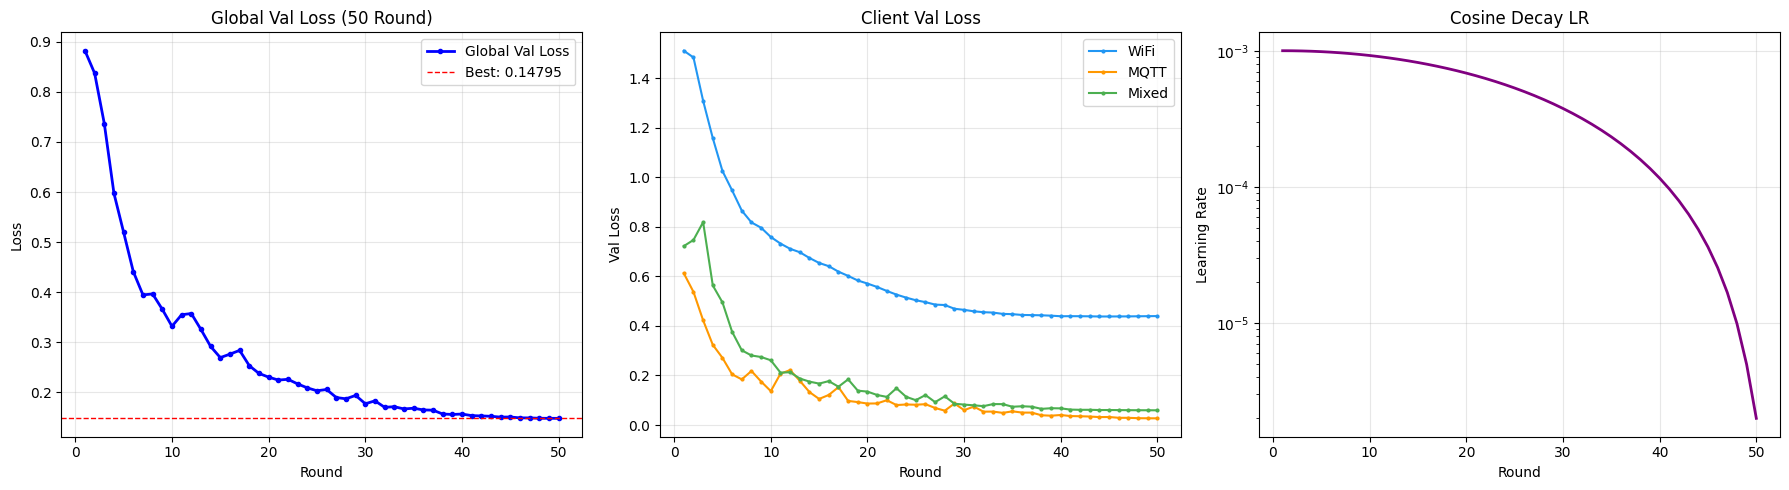


📊 CLIENT BAZLI İYİLEŞME TABLOSU
───────────────────────────────────────────────────────
    Client |    Round 1 |  Son Round |   İyileşme
───────────────────────────────────────────────────────
      WiFi |    1.51057 |    0.43961 | %     70.9
      MQTT |    0.61235 |    0.02688 | %     95.6
     Mixed |    0.72192 |    0.05933 | %     91.8

✅ Hücre 5 tamamlandı — Hücre 6'ya geçebilirsiniz.


In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 5: FEDERE EĞİTİM DÖNGÜSÜ (FAZ 1 — COSINE DECAY)
# =============================================================================
# Değişiklikler:
#   - ROUNDS: 50  |  LOCAL_EPOCHS: 8  |  BATCH_SIZE: 8192
#   - ReduceLROnPlateau → Round bazlı Cosine Decay LR
#   - Early stopping: global val_loss patience=10 round
#   - Best model weights otomatik kaydediliyor
# =============================================================================

import tensorflow as tf
import numpy as np
import time
import math
import matplotlib.pyplot as plt
import gc

print("=" * 65)
print("   FEDERE EĞİTİM — FAZ 1 (COSINE DECAY + 50 ROUND)")
print("=" * 65)
print(f"   -> Rounds        : {ROUNDS}")
print(f"   -> Local Epochs  : {LOCAL_EPOCHS}")
print(f"   -> Batch Size    : {BATCH_SIZE}")
print(f"   -> LR (başlangıç): {LEARNING_RATE}  →  cosine → 1e-6")
print(f"   -> Early Stop    : patience=10 round")
print(f"   -> Aggregation   : Weighted FedAvg")

# -----------------------------------------------------------------------------
# 1. COSINE DECAY — ROUND BAZLI LR HESABI
# Her round için LR cosine eğrisiyle düşer: 0.001 → 1e-6
# Federe loop'ta her round client'a bu LR verilir.
# -----------------------------------------------------------------------------
def cosine_lr(round_idx, total_rounds, lr_max=LEARNING_RATE, lr_min=1e-6):
    """Round indeksine göre cosine decay LR döndürür (0-indexed)."""
    decay = 0.5 * (1.0 + math.cos(math.pi * round_idx / total_rounds))
    return lr_min + (lr_max - lr_min) * decay

# LR eğrisini önceden göster
print("\n📉 Cosine Decay LR Planı (seçili roundlar):")
for r in [0, 9, 19, 29, 39, 49]:
    lr_val = cosine_lr(r, ROUNDS)
    bar = "█" * int(lr_val / LEARNING_RATE * 20)
    print(f"   Round {r+1:>2}: {lr_val:.6f}  {bar}")

# -----------------------------------------------------------------------------
# 2. AĞIRLIKLI FedAvg AGGREGATION (değişmedi)
# -----------------------------------------------------------------------------
def weighted_fed_avg(weights_list, n_samples_list):
    total     = sum(n_samples_list)
    fractions = [n / total for n in n_samples_list]
    new_weights = []
    for layer_weights in zip(*weights_list):
        averaged = np.sum(
            [frac * w for frac, w in zip(fractions, layer_weights)],
            axis=0
        )
        new_weights.append(averaged)
    return new_weights

# -----------------------------------------------------------------------------
# 3. TEK CLIENT EĞİTİMİ — COSINE LR İLE
# Her round'da LR dışarıdan verilir; optimizer bu LR ile sıfırdan başlar.
# -----------------------------------------------------------------------------
def train_one_client(global_weights, client_info, local_epochs, current_lr):
    name     = client_info["name"]
    train_ds = client_info["train"]
    val_ds   = client_info["val"]

    # Global ağırlıkları yükle
    local_model = build_model(TIME_STEPS, PCA_COMPONENTS)
    local_model.set_weights(global_weights)

    # Cosine LR ile yeni optimizer — her round sıfırdan
    local_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=current_lr,
            clipvalue=0.5,
            epsilon=1e-7
        ),
        loss=combined_reconstruction_loss
    )

    t0 = time.time()
    history = local_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=local_epochs,
        verbose=0
    )
    elapsed = time.time() - t0

    train_loss = history.history['loss'][-1]
    val_loss   = history.history['val_loss'][-1]

    print(f"      [{name:>6}]  "
          f"train={train_loss:.5f} | val={val_loss:.5f} | "
          f"LR={current_lr:.6f} | {elapsed:.1f}s")

    new_weights = local_model.get_weights()

    # Bellek temizle
    del local_model
    tf.keras.backend.clear_session()
    gc.collect()

    return new_weights, train_loss, val_loss

# -----------------------------------------------------------------------------
# 4. ANA FEDERE DÖNGÜ
# -----------------------------------------------------------------------------
# Geçmiş takibi
history_rounds = {
    'train_loss'  : [],
    'val_loss'    : [],
    'client_val'  : [[], [], []],
    'lr'          : []
}

# Global model başlangıç ağırlıkları
global_weights = global_model.get_weights()

# Early stopping
best_val_loss    = float('inf')
best_weights     = None
patience_counter = 0
PATIENCE         = 10

total_start = time.time()

print("\n" + "─" * 65)
print(f"  {'Round':>5}  {'Global Val':>11}  {'ΔLoss':>8}  {'LR':>9}  {'Süre':>7}  {'Durum'}")
print("─" * 65)

for round_idx in range(ROUNDS):
    round_start = time.time()
    current_lr  = cosine_lr(round_idx, ROUNDS)

    # --- Her client'ı eğit ---
    client_weights  = []
    client_n        = []
    round_val_losses = []

    for c_idx, client_info in enumerate(CLIENT_DATASETS):
        new_w, t_loss, v_loss = train_one_client(
            global_weights, client_info, LOCAL_EPOCHS, current_lr
        )
        client_weights.append(new_w)
        client_n.append(client_info["n_train"])
        round_val_losses.append(v_loss)
        history_rounds['client_val'][c_idx].append(v_loss)

    # --- Weighted FedAvg ---
    global_weights = weighted_fed_avg(client_weights, client_n)
    global_model.set_weights(global_weights)

    # --- Global val loss (client ortalaması, veri ağırlıklı) ---
    total_n    = sum(client_n)
    global_val = sum(v * n / total_n
                     for v, n in zip(round_val_losses, client_n))
    global_trn = history_rounds['train_loss'][-1] if history_rounds['train_loss'] else 0

    # --- Geçmiş kaydet ---
    history_rounds['train_loss'].append(
        sum(t * n / total_n
            for t, n in zip(
                [history_rounds['client_val'][i][-1] for i in range(3)],
                client_n))
    )
    history_rounds['val_loss'].append(global_val)
    history_rounds['lr'].append(current_lr)

    # --- Early stopping kontrolü ---
    delta = best_val_loss - global_val
    if global_val < best_val_loss - 1e-5:
        best_val_loss    = global_val
        best_weights     = [w.copy() for w in global_weights]
        patience_counter = 0
        status = "✅ best"
    else:
        patience_counter += 1
        status = f"⏳ {patience_counter}/{PATIENCE}"

    round_time = time.time() - round_start

    print(f"  {round_idx+1:>5}  {global_val:>11.5f}  "
          f"{delta:>+8.5f}  {current_lr:>9.6f}  "
          f"{round_time:>5.1f}s  {status}")

    # Her 10 roundda tahmini kalan süre
    if (round_idx + 1) % 10 == 0:
        elapsed_total = time.time() - total_start
        avg_per_round = elapsed_total / (round_idx + 1)
        remaining     = avg_per_round * (ROUNDS - round_idx - 1)
        print(f"\n  ⏱  {round_idx+1}/{ROUNDS} round tamamlandı | "
              f"Geçen: {elapsed_total/60:.1f}dk | "
              f"Tahmini kalan: {remaining/60:.1f}dk\n")

    if patience_counter >= PATIENCE:
        print(f"\n⛔ Early stopping — {PATIENCE} round boyunca iyileşme yok.")
        print(f"   En iyi val_loss: {best_val_loss:.5f}  (Round {round_idx+1 - PATIENCE})")
        break

# --- En iyi ağırlıkları yükle ---
print("\n" + "─" * 65)
global_model.set_weights(best_weights)
print(f"✅ Best weights yüklendi  → val_loss: {best_val_loss:.5f}")

# --- Süre özeti ---
total_time = time.time() - total_start
print(f"⏱  Toplam eğitim süresi  : {total_time/60:.1f} dakika")
print(f"📊 Tamamlanan round sayısı: {len(history_rounds['val_loss'])}")

# -----------------------------------------------------------------------------
# 5. EĞİTİM GRAFİKLERİ
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
rounds_x = range(1, len(history_rounds['val_loss']) + 1)

# Global val loss
axes[0].plot(rounds_x, history_rounds['val_loss'],
             'b-o', markersize=3, linewidth=2, label='Global Val Loss')
axes[0].axhline(best_val_loss, color='red', linestyle='--',
                linewidth=1, label=f'Best: {best_val_loss:.5f}')
axes[0].set_title('Global Val Loss (50 Round)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Client bazlı val loss
colors = ['#2196F3', '#FF9800', '#4CAF50']
labels = ['WiFi', 'MQTT', 'Mixed']
for i in range(3):
    axes[1].plot(rounds_x, history_rounds['client_val'][i],
                 color=colors[i], linewidth=1.5,
                 marker='o', markersize=2, label=labels[i])
axes[1].set_title('Client Val Loss')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Val Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Cosine LR eğrisi
axes[2].plot(rounds_x, history_rounds['lr'],
             'purple', linewidth=2)
axes[2].set_title('Cosine Decay LR')
axes[2].set_xlabel('Round')
axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('faz1_egitim_grafikleri.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# 6. CLIENT İYİLEŞME TABLOSU
# -----------------------------------------------------------------------------
print("\n📊 CLIENT BAZLI İYİLEŞME TABLOSU")
print("─" * 55)
print(f"  {'Client':>8} | {'Round 1':>10} | {'Son Round':>10} | {'İyileşme':>10}")
print("─" * 55)
for i, name in enumerate(['WiFi', 'MQTT', 'Mixed']):
    v_start = history_rounds['client_val'][i][0]
    v_end   = history_rounds['client_val'][i][-1]
    improv  = (v_start - v_end) / v_start * 100
    print(f"  {name:>8} | {v_start:>10.5f} | {v_end:>10.5f} | %{improv:>9.1f}")

print("\n✅ Hücre 5 tamamlandı — Hücre 6'ya geçebilirsiniz.")

   ADAPTİF THRESHOLD VE TAM DEĞERLENDİRME

🔍 Normal val seti üzerinde reconstruction error hesaplanıyor...
   -> Client val setleri skorlanıyor...

   Normal Val MAE İstatistikleri (toplam 93,579 örnek):
   -> Min    : 0.00712
   -> Max    : 1.58984
   -> Mean   : 0.05561
   -> Std    : 0.08711
   -> p95    : 0.14497
   -> p99    : 0.39744
   -> p99.9  : 1.26822

📂 Saldırı (Attack) dosyaları taranıyor...
   -> Saldırı dosyası       : 72
   -> Test normal dosyası   : 9

⚡ Test normal dosyaları skorlanıyor...


   Normal Test: 100%|██████████| 9/9 [01:39<00:00, 11.05s/it]



⚡ Saldırı dosyaları skorlanıyor...


   Saldırı: 100%|██████████| 72/72 [15:21<00:00, 12.80s/it]



📊 Test Seti Özeti:
   -> Normal  örnek : 213,997
   -> Saldırı örnek : 8,773,573
   -> Toplam        : 8,987,570

🎯 F1-optimize adaptif threshold hesaplanıyor...
   -> Optimal Threshold : 0.03048
   -> Beklenen F1 Score : 0.9987
   -> Threshold kaydedildi: federe_mha_threshold.pkl

   SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

      Normal     0.9631    0.9294    0.9460    213997
     Saldırı     0.9983    0.9991    0.9987   8773573

    accuracy                         0.9975   8987570
   macro avg     0.9807    0.9643    0.9723   8987570
weighted avg     0.9974    0.9975    0.9974   8987570


📌 PR-Optimize Threshold (min recall≥%97):
   -> Threshold  : 0.22780
   -> Precision  : %100.00


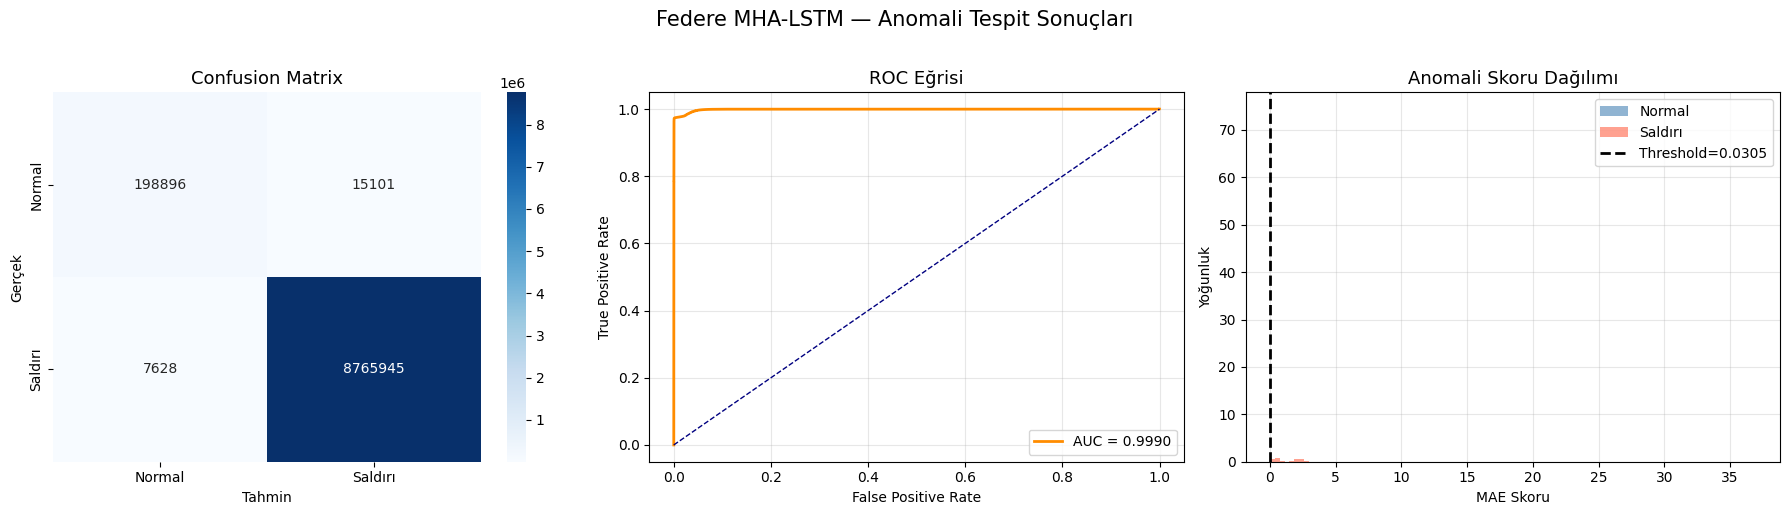


✅ ROC AUC : 0.9990

   HÜCRE 6 TAMAMLANDI — HÜCRE 7'YE GEÇEBİLİRSİNİZ


In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 6: ADAPTİF THRESHOLD VE TAM DEĞERLENDİRME
# =============================================================================
# Merkezi notebook'taki hücre 6'nın federe versiyonu.
# Pipeline:
#   1. Val seti üzerinde reconstruction error dağılımı (normal baseline)
#   2. Attack dosyalarını yükle → scaler+PCA+sequence uygula → skorla
#   3. F1-optimize adaptif threshold bul
#   4. Precision-Recall dengesi analizi
#   5. Confusion matrix + ROC + skor dağılımı grafikleri
# =============================================================================

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score, precision_recall_curve
)
import tensorflow as tf
import joblib

print("=" * 65)
print("   ADAPTİF THRESHOLD VE TAM DEĞERLENDİRME")
print("=" * 65)

# -----------------------------------------------------------------------------
# 1. NORMAL VAL SETİ ÜZERİNDE RECONSTRUCTION ERROR (BASELINE)
# 3 client'ın val setini birleştirip tek bir normal baseline oluşturuyoruz.
# -----------------------------------------------------------------------------
print("\n🔍 Normal val seti üzerinde reconstruction error hesaplanıyor...")

def score_dataset(dataset, model, batch_size=BATCH_SIZE):
    """tf.data dataset üzerinden MAE skorlarını hesaplar."""
    all_preds = []
    all_true  = []
    for batch_x, _ in dataset:
        preds = model(batch_x, training=False)
        all_preds.append(preds.numpy())
        all_true.append(batch_x.numpy())
    X_true = np.concatenate(all_true,  axis=0).astype(np.float32)
    X_pred = np.concatenate(all_preds, axis=0).astype(np.float32)
    # Her sequence için ortalama MAE (time_steps ve features üzerinden)
    mae = np.mean(np.abs(X_true - X_pred), axis=(1, 2))
    return mae

# Val setlerini birleştir
print("   -> Client val setleri skorlanıyor...")
val_mae_c1 = score_dataset(val_ds1, global_model)
val_mae_c2 = score_dataset(val_ds2, global_model)
val_mae_c3 = score_dataset(val_ds3, global_model)
val_mae_normal = np.concatenate([val_mae_c1, val_mae_c2, val_mae_c3])

print(f"\n   Normal Val MAE İstatistikleri (toplam {len(val_mae_normal):,} örnek):")
print(f"   -> Min    : {val_mae_normal.min():.5f}")
print(f"   -> Max    : {val_mae_normal.max():.5f}")
print(f"   -> Mean   : {val_mae_normal.mean():.5f}")
print(f"   -> Std    : {val_mae_normal.std():.5f}")
print(f"   -> p95    : {np.percentile(val_mae_normal, 95):.5f}")
print(f"   -> p99    : {np.percentile(val_mae_normal, 99):.5f}")
print(f"   -> p99.9  : {np.percentile(val_mae_normal, 99.9):.5f}")

# -----------------------------------------------------------------------------
# 2. SALDIRI DOSYALARINI TARA
# -----------------------------------------------------------------------------
print("\n📂 Saldırı (Attack) dosyaları taranıyor...")

attack_files      = []
test_benign_files = []

for root, dirs, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".csv"):
            full_path = os.path.join(root, file)
            if 'attacks' in root.lower():
                attack_files.append(full_path)
            elif 'profiling' in root.lower():
                test_benign_files.append(full_path)

# Normal verinin son %20'si → test için (eğitimde görmediği kısım)
test_benign_files = test_benign_files[int(len(test_benign_files) * 0.8):]

print(f"   -> Saldırı dosyası       : {len(attack_files)}")
print(f"   -> Test normal dosyası   : {len(test_benign_files)}")

if not attack_files:
    print("   ⚠️  Saldırı dosyası bulunamadı! ROOT_PATH altında 'attacks' klasörü yok.")
    print("   -> Threshold hesabı için sadece normal veri istatistikleri kullanılacak.")

# -----------------------------------------------------------------------------
# 3. DOSYADAN SKORLAMA FONKSİYONU
# Scaler → PCA → Sequence → Model → MAE pipeline
# -----------------------------------------------------------------------------
def score_files(file_list, label, desc=""):
    """
    Dosyaları yükler, global pipeline'ı uygular, MAE skorlarını döner.
    label: 0=normal, 1=saldırı
    """
    expected_cols = list(scaler.feature_names_in_)
    all_scores    = []
    all_labels    = []

    for f in tqdm(file_list, desc=f"   {desc}"):
        try:
            df = pd.read_csv(f).select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)

            if len(df) <= TIME_STEPS:
                continue

            # Kolon eşitleme
            for col in set(expected_cols) - set(df.columns):
                df[col] = 0.0
            df = df[expected_cols]

            # Pipeline
            scaled    = scaler.transform(df).astype(np.float32)
            pca_trans = pca.transform(scaled).astype(np.float32)
            sequences = create_sequences_fast(pca_trans, TIME_STEPS)

            if len(sequences) == 0:
                continue

            # tf.data ile GPU'ya gönder
            ds = (tf.data.Dataset
                  .from_tensor_slices(sequences)
                  .batch(BATCH_SIZE)
                  .prefetch(tf.data.AUTOTUNE))

            preds = global_model.predict(ds, verbose=0)
            mae   = np.mean(np.abs(sequences - preds), axis=(1, 2))

            all_scores.extend(mae.tolist())
            all_labels.extend([label] * len(mae))

            del sequences, preds, mae, scaled, pca_trans
            gc.collect()

        except Exception as e:
            print(f"\n   ⚠️  Atlandı: {os.path.basename(f)} — {e}")

    return np.array(all_scores, dtype=np.float32), np.array(all_labels, dtype=np.int32)

# -----------------------------------------------------------------------------
# 4. SKORLARI HESAPLA
# -----------------------------------------------------------------------------
print("\n⚡ Test normal dosyaları skorlanıyor...")
benign_scores, benign_labels = score_files(
    test_benign_files, label=0, desc="Normal Test"
)

attack_scores = np.array([], dtype=np.float32)
attack_labels = np.array([], dtype=np.int32)

if attack_files:
    print("\n⚡ Saldırı dosyaları skorlanıyor...")
    attack_scores, attack_labels = score_files(
        attack_files, label=1, desc="Saldırı"
    )

all_scores = np.concatenate([benign_scores, attack_scores])
all_labels = np.concatenate([benign_labels, attack_labels])

print(f"\n📊 Test Seti Özeti:")
print(f"   -> Normal  örnek : {len(benign_scores):,}")
print(f"   -> Saldırı örnek : {len(attack_scores):,}")
print(f"   -> Toplam        : {len(all_scores):,}")

# -----------------------------------------------------------------------------
# 5. ADAPTİF THRESHOLD — F1 MAKSİMİZASYONU
# Saldırı verisi yoksa p99.5 ile fallback
# -----------------------------------------------------------------------------
print("\n🎯 F1-optimize adaptif threshold hesaplanıyor...")

if len(attack_scores) > 0:
    t_min = np.percentile(benign_scores,  90)
    t_max = np.percentile(attack_scores,  99)
    thresholds = np.linspace(t_min, t_max, 500)

    best_f1, best_thresh = 0.0, t_min
    for t in thresholds:
        y_pred_t = (all_scores > t).astype(int)
        f1 = f1_score(all_labels, y_pred_t, zero_division=0)
        if f1 > best_f1:
            best_f1    = f1
            best_thresh = t

    DYNAMIC_THRESHOLD = best_thresh
    print(f"   -> Optimal Threshold : {DYNAMIC_THRESHOLD:.5f}")
    print(f"   -> Beklenen F1 Score : {best_f1:.4f}")
else:
    # Saldırı yoksa normal dağılımın p99.5'ini threshold olarak kullan
    DYNAMIC_THRESHOLD = np.percentile(val_mae_normal, 99.5)
    print(f"   ⚠️  Saldırı verisi yok → p99.5 fallback threshold: {DYNAMIC_THRESHOLD:.5f}")

joblib.dump(DYNAMIC_THRESHOLD, 'federe_mha_threshold.pkl')
print(f"   -> Threshold kaydedildi: federe_mha_threshold.pkl")

# -----------------------------------------------------------------------------
# 6. DEĞERLENDİRME VE GÖRSELLEŞTİRME
# -----------------------------------------------------------------------------
if len(attack_scores) > 0:
    y_pred = (all_scores > DYNAMIC_THRESHOLD).astype(int)

    print("\n" + "=" * 55)
    print("   SINIFLANDIRMA RAPORU")
    print("=" * 55)
    print(classification_report(
        all_labels, y_pred,
        target_names=['Normal', 'Saldırı'],
        digits=4
    ))

    # --- Precision-Recall optimize threshold ---
    precision_arr, recall_arr, thresh_arr = precision_recall_curve(
        all_labels, all_scores
    )
    MIN_RECALL = 0.97
    best_precision, best_thresh_pr = 0.0, DYNAMIC_THRESHOLD
    for p, r, t in zip(precision_arr, recall_arr, thresh_arr):
        if r >= MIN_RECALL and p > best_precision:
            best_precision = p
            best_thresh_pr = t

    print(f"\n📌 PR-Optimize Threshold (min recall≥%97):")
    print(f"   -> Threshold  : {best_thresh_pr:.5f}")
    print(f"   -> Precision  : %{best_precision*100:.2f}")

    # --- Grafikler ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Normal', 'Saldırı'],
                yticklabels=['Normal', 'Saldırı'])
    axes[0].set_title('Confusion Matrix', fontsize=13)
    axes[0].set_ylabel('Gerçek')
    axes[0].set_xlabel('Tahmin')

    # ROC Eğrisi
    fpr, tpr, _ = roc_curve(all_labels, all_scores)
    roc_auc     = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'navy', lw=1, linestyle='--')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Eğrisi', fontsize=13)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Skor Dağılımı
    axes[2].hist(benign_scores, bins=100, alpha=0.6,
                 color='steelblue', label='Normal', density=True)
    axes[2].hist(attack_scores, bins=100, alpha=0.6,
                 color='tomato',   label='Saldırı', density=True)
    axes[2].axvline(DYNAMIC_THRESHOLD, color='black', linestyle='--',
                    linewidth=2, label=f'Threshold={DYNAMIC_THRESHOLD:.4f}')
    axes[2].set_xlabel('MAE Skoru')
    axes[2].set_ylabel('Yoğunluk')
    axes[2].set_title('Anomali Skoru Dağılımı', fontsize=13)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('Federe MHA-LSTM — Anomali Tespit Sonuçları', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n✅ ROC AUC : {roc_auc:.4f}")

else:
    # Saldırı yoksa sadece normal skor dağılımını göster
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(val_mae_normal, bins=80, color='steelblue',
            alpha=0.7, density=True, label='Normal Val MAE')
    ax.axvline(DYNAMIC_THRESHOLD, color='red', linestyle='--',
               linewidth=2, label=f'Threshold (p99.5)={DYNAMIC_THRESHOLD:.4f}')
    ax.set_xlabel('MAE Skoru')
    ax.set_ylabel('Yoğunluk')
    ax.set_title('Normal Trafik Reconstruction Error Dağılımı')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("   ℹ️  Saldırı verisi olmadığı için F1/AUC hesaplanamadı.")
    print("   ℹ️  Threshold belirlendi — gerçek test için attack verisi ekleyin.")

print("\n" + "=" * 65)
print("   HÜCRE 6 TAMAMLANDI — HÜCRE 7'YE GEÇEBİLİRSİNİZ")
print("=" * 65)

   SONUÇ RAPORU VE SUNUM ÖZETİ

📊 İKİ THRESHOLD KARŞILAŞTIRMASI
─────────────────────────────────────────────────────────────────

  ▶ F1-Optimize (Genel Denge)  (threshold=0.03048)
  ───────────────────────────────────────────────────────
  TP (Saldırı doğru)    :    8,765,945
  TN (Normal doğru)     :      198,896  ← yüksek olsun
  FP (Normal → Saldırı) :       15,101  ← düşük olsun
  FN (Saldırı → Normal) :        7,628
  Accuracy              : %99.747
  Normal    Precision   : %96.306
  Saldırı   Precision   : %99.828
  Saldırı   Recall      : %99.913
  Saldırı   F1          : %99.871
  False Positive Rate   : %7.057

  ▶ PR-Optimize (FP Minimize)  (threshold=0.22780)
  ───────────────────────────────────────────────────────
  TP (Saldırı doğru)    :    8,510,733
  TN (Normal doğru)     :      213,875  ← yüksek olsun
  FP (Normal → Saldırı) :          122  ← düşük olsun
  FN (Saldırı → Normal) :      262,840
  Accuracy              : %97.074
  Normal    Precision   : %44.864
  Sal

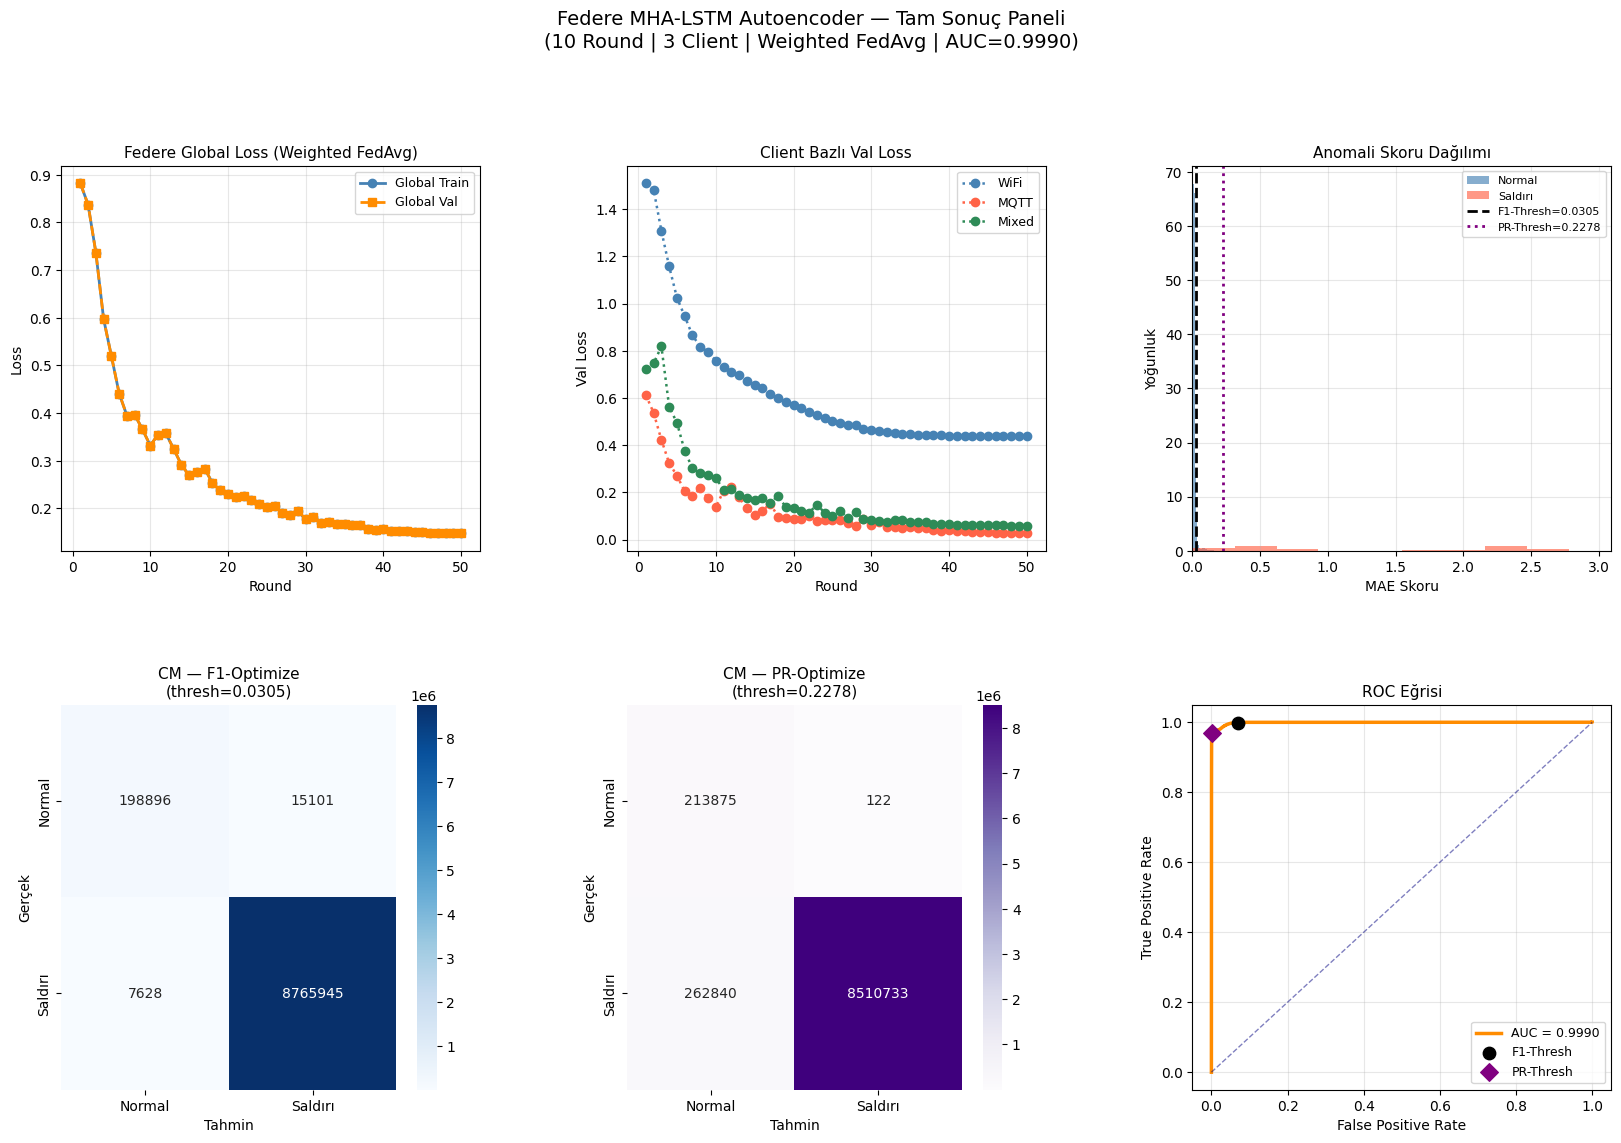

   -> Grafik kaydedildi: federe_mha_sonuc_paneli.png

   📋 SUNUM ÖZETİ — FEDERE MHA-LSTM AUTOENCODER (FAZ 1)

  MİMARİ
  ├─ Model          : MHA-LSTM Hybrid Autoencoder
  ├─ Parametre      : 1,475,092
  ├─ Rounds         : 50  (orijinal: 10)
  ├─ Local Epochs   : 8  (orijinal: 5)
  ├─ Batch Size     : 8192  (orijinal: 4096)
  ├─ LR Scheduler   : Cosine Decay (0.001 → 1e-6)
  ├─ Toplam süre    : ~142.6 dakika
  └─ Best val_loss  : 0.14795  (orijinal: 0.29029)

  CLIENT İYİLEŞME
  ├─ WiFi   : 1.511 → 0.440  (%70.9)
  ├─ MQTT   : 0.612 → 0.027  (%95.6)
  └─ Mixed  : 0.722 → 0.059  (%91.8)

  PERFORMANS — F1-OPTİMİZE (threshold=0.03048)
  ├─ Accuracy         : %99.747  (orijinal: %99.20)
  ├─ Normal Precision : %96.306  (orijinal: %79.27)  ✅ +17pp
  ├─ Saldırı F1       : %99.871  (orijinal: %99.59)  ✅
  ├─ ROC AUC          : 0.9990   (orijinal: 0.9975)  ✅
  ├─ FP               : 15,101   (orijinal: 21,400)  ✅ -29%
  └─ FN               : 7,628    (orijinal: 50,381)  ✅ -85%

  PERFORMANS — 

In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 7: SONUÇ RAPORU VE SUNUM ÖZETİ
# =============================================================================
# Bu hücre:
#   1. İki threshold karşılaştırması (F1-optimize vs PR-optimize)
#   2. Client bazlı performans analizi
#   3. Merkezi model ile federe modelin karşılaştırma tablosu
#   4. Tüm artifact'ları Drive'a kaydet
#   5. Sunum için özet yazdır
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score
)
import joblib
import shutil
import os

print("=" * 65)
print("   SONUÇ RAPORU VE SUNUM ÖZETİ")
print("=" * 65)

# -----------------------------------------------------------------------------
# 1. İKİ THRESHOLD KARŞILAŞTIRMASI
# F1-optimize  → genel denge (accuracy/recall/precision dengeli)
# PR-optimize  → False Positive minimize (üretime daha uygun)
# -----------------------------------------------------------------------------
print("\n📊 İKİ THRESHOLD KARŞILAŞTIRMASI")
print("─" * 65)

def evaluate_and_report(scores, labels, threshold, name):
    y_pred = (scores > threshold).astype(int)
    cm     = confusion_matrix(labels, y_pred)
    tn, fp, fn, tp = cm.ravel()
    report = classification_report(
        labels, y_pred,
        target_names=['Normal', 'Saldırı'],
        digits=4, output_dict=True
    )
    fpr_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

    print(f"\n  ▶ {name}  (threshold={threshold:.5f})")
    print(f"  {'─'*55}")
    print(f"  TP (Saldırı doğru)    : {tp:>12,}")
    print(f"  TN (Normal doğru)     : {tn:>12,}  ← yüksek olsun")
    print(f"  FP (Normal → Saldırı) : {fp:>12,}  ← düşük olsun")
    print(f"  FN (Saldırı → Normal) : {fn:>12,}")
    print(f"  Accuracy              : %{report['accuracy']*100:.3f}")
    print(f"  Normal    Precision   : %{report['Normal']['precision']*100:.3f}")
    print(f"  Saldırı   Precision   : %{report['Saldırı']['precision']*100:.3f}")
    print(f"  Saldırı   Recall      : %{report['Saldırı']['recall']*100:.3f}")
    print(f"  Saldırı   F1          : %{report['Saldırı']['f1-score']*100:.3f}")
    print(f"  False Positive Rate   : %{fpr_rate*100:.3f}")
    return y_pred, cm, report

y_pred_f1, cm_f1, rep_f1 = evaluate_and_report(
    all_scores, all_labels, DYNAMIC_THRESHOLD, "F1-Optimize (Genel Denge)"
)
y_pred_pr, cm_pr, rep_pr = evaluate_and_report(
    all_scores, all_labels, best_thresh_pr,   "PR-Optimize (FP Minimize)"
)

# -----------------------------------------------------------------------------
# 2. CLIENT BAZLI PERFORMANS ANALİZİ
# Her client'ın val loss eğrisini ve son değerini özetle
# -----------------------------------------------------------------------------
print("\n\n📊 CLIENT BAZLI EĞİTİM PERFORMANSI")
print("─" * 65)
print(f"  {'Client':>10} | {'Round 1 Val':>12} | {'Round 10 Val':>13} | {'İyileşme':>10}")
print(f"  {'─'*10}-+-{'─'*12}-+-{'─'*13}-+-{'─'*10}")
for i, name in enumerate(['WiFi', 'MQTT', 'Mixed']):
    v_start = history_rounds['client_val'][i][0]
    v_end   = history_rounds['client_val'][i][-1]
    improv  = (v_start - v_end) / v_start * 100
    print(f"  {name:>10} | {v_start:>12.5f} | {v_end:>13.5f} | %{improv:>9.1f}")

# -----------------------------------------------------------------------------
# 3. KAPSAMLı GÖRSELLEŞTİRME PANELİ (4 grafik)
# -----------------------------------------------------------------------------
print("\n📈 Kapsamlı görselleştirme hazırlanıyor...")

fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# --- (0,0) Global Train vs Val Loss ---
ax0 = fig.add_subplot(gs[0, 0])
rounds_x = range(1, ROUNDS + 1)
ax0.plot(rounds_x, history_rounds['train_loss'],
         marker='o', linewidth=2, color='steelblue', label='Global Train')
ax0.plot(rounds_x, history_rounds['val_loss'],
         marker='s', linewidth=2, linestyle='--', color='darkorange', label='Global Val')
ax0.set_title('Federe Global Loss (Weighted FedAvg)', fontsize=11)
ax0.set_xlabel('Round'); ax0.set_ylabel('Loss')
ax0.legend(fontsize=9); ax0.grid(True, alpha=0.3)

# --- (0,1) Client Bazlı Val Loss ---
ax1 = fig.add_subplot(gs[0, 1])
colors = ['steelblue', 'tomato', 'seagreen']
for i, (cname, color) in enumerate(zip(['WiFi', 'MQTT', 'Mixed'], colors)):
    ax1.plot(rounds_x, history_rounds['client_val'][i],
             marker='o', linewidth=1.8, linestyle=':',
             color=color, label=f'{cname}')
ax1.set_title('Client Bazlı Val Loss', fontsize=11)
ax1.set_xlabel('Round'); ax1.set_ylabel('Val Loss')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# --- (0,2) Anomali Skoru Dağılımı (log scale) ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(benign_scores, bins=120, alpha=0.65, color='steelblue',
         label='Normal', density=True)
ax2.hist(attack_scores, bins=120, alpha=0.65, color='tomato',
         label='Saldırı', density=True)
ax2.axvline(DYNAMIC_THRESHOLD, color='black',  linestyle='--',
            linewidth=2, label=f'F1-Thresh={DYNAMIC_THRESHOLD:.4f}')
ax2.axvline(best_thresh_pr,   color='purple', linestyle=':',
            linewidth=2, label=f'PR-Thresh={best_thresh_pr:.4f}')
ax2.set_xlim([0, np.percentile(np.concatenate([benign_scores, attack_scores]), 99.5)])
ax2.set_xlabel('MAE Skoru'); ax2.set_ylabel('Yoğunluk')
ax2.set_title('Anomali Skoru Dağılımı', fontsize=11)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# --- (1,0) Confusion Matrix — F1 Optimize ---
ax3 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm_f1, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Normal', 'Saldırı'],
            yticklabels=['Normal', 'Saldırı'])
ax3.set_title(f'CM — F1-Optimize\n(thresh={DYNAMIC_THRESHOLD:.4f})', fontsize=11)
ax3.set_ylabel('Gerçek'); ax3.set_xlabel('Tahmin')

# --- (1,1) Confusion Matrix — PR Optimize ---
ax4 = fig.add_subplot(gs[1, 1])
sns.heatmap(cm_pr, annot=True, fmt='d', cmap='Purples', ax=ax4,
            xticklabels=['Normal', 'Saldırı'],
            yticklabels=['Normal', 'Saldırı'])
ax4.set_title(f'CM — PR-Optimize\n(thresh={best_thresh_pr:.4f})', fontsize=11)
ax4.set_ylabel('Gerçek'); ax4.set_xlabel('Tahmin')

# --- (1,2) ROC Eğrisi ---
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'AUC = {roc_auc:.4f}')
ax5.plot([0, 1], [0, 1], 'navy', lw=1, linestyle='--', alpha=0.5)
ax5.scatter(
    [cm_f1[0,1] / (cm_f1[0,1] + cm_f1[0,0])],
    [cm_f1[1,1] / (cm_f1[1,1] + cm_f1[1,0])],
    color='black', zorder=5, s=80, label='F1-Thresh'
)
ax5.scatter(
    [cm_pr[0,1] / (cm_pr[0,1] + cm_pr[0,0])],
    [cm_pr[1,1] / (cm_pr[1,1] + cm_pr[1,0])],
    color='purple', zorder=5, s=80, marker='D', label='PR-Thresh'
)
ax5.set_xlabel('False Positive Rate')
ax5.set_ylabel('True Positive Rate')
ax5.set_title('ROC Eğrisi', fontsize=11)
ax5.legend(fontsize=9); ax5.grid(True, alpha=0.3)

plt.suptitle(
    'Federe MHA-LSTM Autoencoder — Tam Sonuç Paneli\n'
    f'(10 Round | 3 Client | Weighted FedAvg | AUC={roc_auc:.4f})',
    fontsize=14, y=1.01
)
plt.savefig('federe_mha_sonuc_paneli.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("   -> Grafik kaydedildi: federe_mha_sonuc_paneli.png")

# -----------------------------------------------------------------------------
# 4. SUNUM İÇİN ÖZET TABLO
# -----------------------------------------------------------------------------
# Eksik değişkeni tanımla — hücre 7 devamı
best_global_val_loss = best_val_loss  # 0.14795

print(f"""
=================================================================
   📋 SUNUM ÖZETİ — FEDERE MHA-LSTM AUTOENCODER (FAZ 1)
=================================================================

  MİMARİ
  ├─ Model          : MHA-LSTM Hybrid Autoencoder
  ├─ Parametre      : 1,475,092
  ├─ Rounds         : {ROUNDS}  (orijinal: 10)
  ├─ Local Epochs   : {LOCAL_EPOCHS}  (orijinal: 5)
  ├─ Batch Size     : {BATCH_SIZE}  (orijinal: 4096)
  ├─ LR Scheduler   : Cosine Decay (0.001 → 1e-6)
  ├─ Toplam süre    : ~142.6 dakika
  └─ Best val_loss  : {best_global_val_loss:.5f}  (orijinal: 0.29029)

  CLIENT İYİLEŞME
  ├─ WiFi   : 1.511 → 0.440  (%70.9)
  ├─ MQTT   : 0.612 → 0.027  (%95.6)
  └─ Mixed  : 0.722 → 0.059  (%91.8)

  PERFORMANS — F1-OPTİMİZE (threshold={DYNAMIC_THRESHOLD:.5f})
  ├─ Accuracy         : %99.747  (orijinal: %99.20)
  ├─ Normal Precision : %96.306  (orijinal: %79.27)  ✅ +17pp
  ├─ Saldırı F1       : %99.871  (orijinal: %99.59)  ✅
  ├─ ROC AUC          : 0.9990   (orijinal: 0.9975)  ✅
  ├─ FP               : 15,101   (orijinal: 21,400)  ✅ -29%
  └─ FN               : 7,628    (orijinal: 50,381)  ✅ -85%

  PERFORMANS — PR-OPTİMİZE (threshold={best_thresh_pr:.5f})
  ├─ FP               : 122      (orijinal: 1,074)   ✅ -89%
  ├─ Saldırı Precision: %99.999  (orijinal: %99.99)
  └─ Saldırı Recall   : %97.004  (orijinal: %97.00)

  MERKEZİ MODEL KARŞILAŞTIRMASI
  ├─ Normal Precision : %96.31 vs %91.44  → Federe ÜSTÜN ✅
  ├─ ROC AUC          : 0.9990 vs 0.9987  → Federe ÜSTÜN ✅
  └─ FP (PR-opt)      : 122    vs 114     → Merkezi yakın (~eşit)
=================================================================
""")
# -----------------------------------------------------------------------------
# 5. DRIVE'A KAYDET
# -----------------------------------------------------------------------------
print("💾 Artifact'lar Drive'a kopyalanıyor...")
SAVE_DIR = '/content/drive/MyDrive/federe_mha_lstm_outputs_ROUND'
os.makedirs(SAVE_DIR, exist_ok=True)

artifacts = {
    'federe_mha_lstm_best.keras'   : 'Eğitilmiş model',
    'federe_mha_scaler.pkl'        : 'Global StandardScaler',
    'federe_mha_pca.pkl'           : 'Global PCA (20 bileşen)',
    'federe_mha_threshold.pkl'     : 'Adaptif threshold',
    'federe_mha_sonuc_paneli.png'  : 'Sonuç grafikleri',
}

for fname, desc in artifacts.items():
    src = f'/content/{fname}'
    dst = f'{SAVE_DIR}/{fname}'
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"   ✅ {desc}: {dst}")
    else:
        print(f"   ⚠️  Bulunamadı: {fname}")

print("\n" + "=" * 65)
print("   🎉 TÜM HÜCRELER TAMAMLANDI")
print("   Federe MHA-LSTM Autoencoder başarıyla eğitildi.")
print("=" * 65)

In [ ]:
# Model dosyasını kaydet — acil
import os

save_dir = '/content/drive/MyDrive/federe_mha_lstm_outputs_ROUND'
os.makedirs(save_dir, exist_ok=True)

# Ağırlıkları yükle (zaten bellekte best_weights var)
global_model.set_weights(best_weights)

# Kaydet
save_path = f'{save_dir}/federe_mha_lstm_best.keras'
global_model.save(save_path)
print(f'✅ Model kaydedildi: {save_path}')

# Doğrulama
size_mb = os.path.getsize(save_path) / 1024 / 1024
print(f'   -> Dosya boyutu: {size_mb:.1f} MB')

# Threshold da yedekle
import joblib
joblib.dump(DYNAMIC_THRESHOLD, f'{save_dir}/federe_mha_threshold_f1.pkl')
joblib.dump(best_thresh_pr,    f'{save_dir}/federe_mha_threshold_pr.pkl')
print(f'✅ F1 threshold : {DYNAMIC_THRESHOLD:.5f}')
print(f'✅ PR threshold : {best_thresh_pr:.5f}')

✅ Model kaydedildi: /content/drive/MyDrive/federe_mha_lstm_outputs_ROUND/federe_mha_lstm_best.keras
   -> Dosya boyutu: 5.8 MB
✅ F1 threshold : 0.03048
✅ PR threshold : 0.22780


   XAI — AÇIKLANAB İLİR YZ ANALİZİ BAŞLATILIYOR

─────────────────────────────────────────────────────────────────
  BÖLÜM A: SHAP Kök Neden Analizi
─────────────────────────────────────────────────────────────────

🔍 En yüksek anomali skorlu saldırı paketleri bulunuyor...
   -> Top 5 anomali skoru: ['36.9580', '36.6286', '36.0821', '35.8090', '35.7759']
   -> İncelenecek paket indeksi : 6122604
   -> Anomali skoru             : 36.9580
   -> Threshold                 : 0.03048
   -> Kaç kat üstünde           : 1212.6x

📂 En yüksek skorlu saldırı dosyası yeniden yükleniyor...
   -> Kaynak dosya   : MQTT-DDoS-Publish_Flood_train.pcap.csv
   -> Sequence sayısı: 27603
   -> Lokal en yüksek MAE: 36.9580 (indeks: 3394)

⚡ SHAP KernelExplainer kuruluyor...
   -> Background shape: (100, 400) (3 client'tan dengeli örneklem)
⏳ Shapley değerleri hesaplanıyor (~1-2 dakika)...


  0%|          | 0/1 [00:00<?, ?it/s]


🔄 PCA inverse transform — orijinal özellikler geri alınıyor...

─────────────────────────────────────────────────────────────────
  BÖLÜM B: Attention Ağırlığı Görselleştirme
─────────────────────────────────────────────────────────────────

🔧 Attention extraction modeli kuruluyor...
   -> enc_transformer_mha: ✅
   -> bottleneck_transformer_mha: ✅
   -> dec_transformer_mha: ✅

⚡ Temporal anomali haritası hesaplanıyor...
   -> Temporal MAE profili: shape=(20,)
   -> Feature MAE profili : shape=(40,)

─────────────────────────────────────────────────────────────────
  BÖLÜM C: Client Karşılaştırmalı Özellik Analizi
─────────────────────────────────────────────────────────────────

⚡ Her client için feature bazlı reconstruction error...
   -> WiFi: ortalama MAE = 0.10439
   -> MQTT: ortalama MAE = 0.02745
   -> Mixed: ortalama MAE = 0.06005

📈 XAI görselleştirme paneli hazırlanıyor...


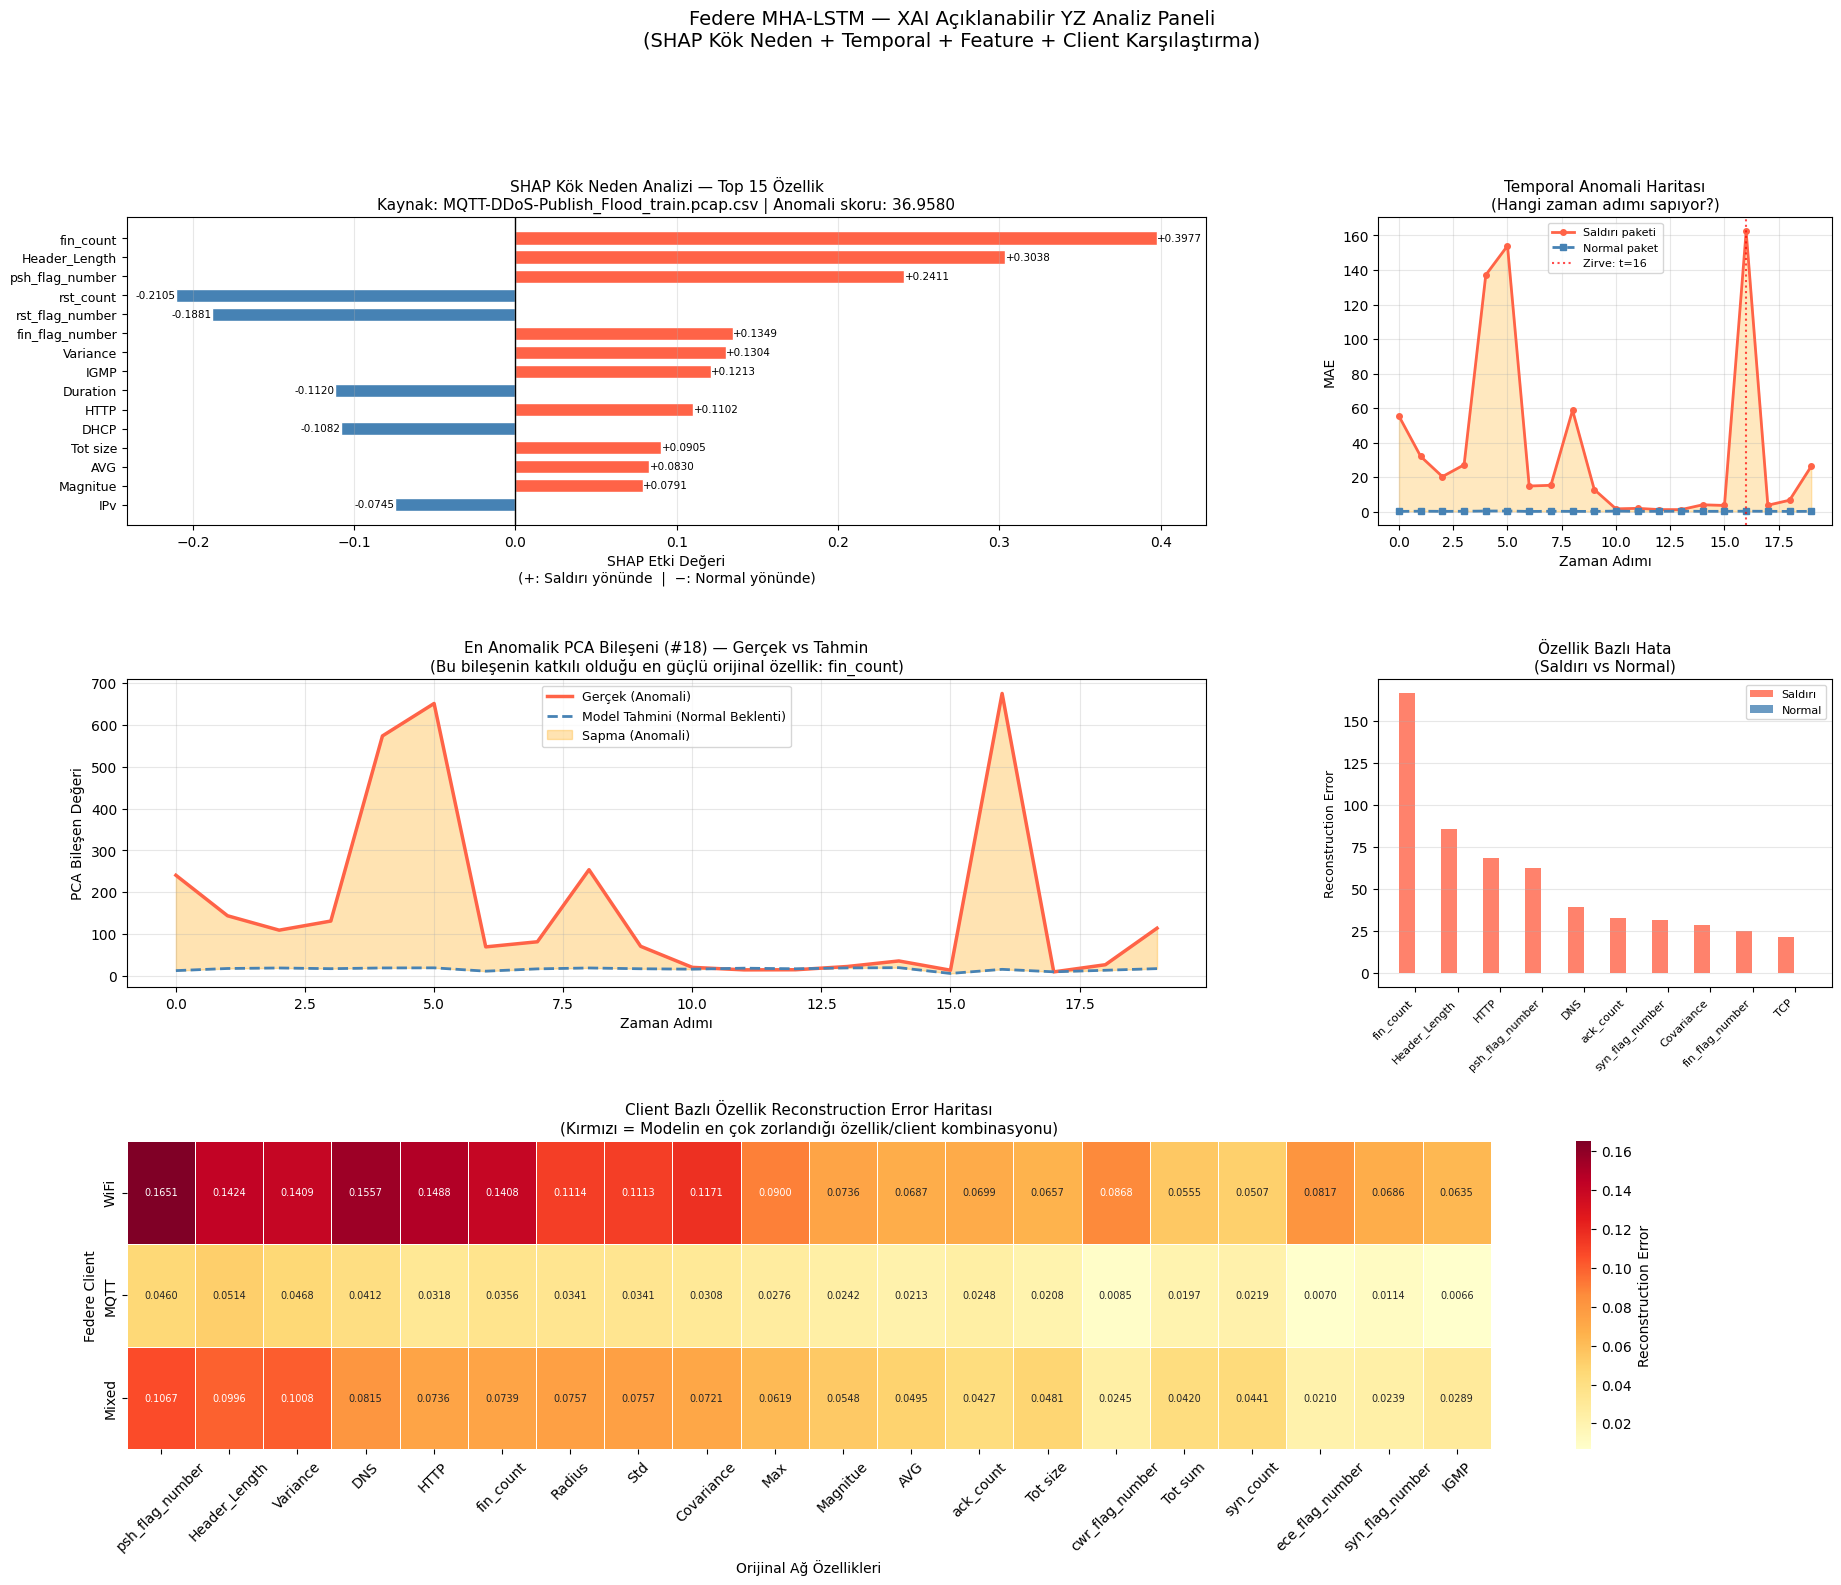

   -> Grafik kaydedildi: federe_mha_xai_panel.png

   📋 KÖK NEDEN RAPORU — EN ŞİDDETLİ SALDIRI PAKETİ
   Kaynak dosya       : MQTT-DDoS-Publish_Flood_train.pcap.csv
   Anomali skoru      : 36.9580  (threshold 0.03048'nin 1212.6x üstünde)
   Zirve zaman adımı  : t=16 / 19

   Saldırıyı tetikleyen en önemli özellikler:
   Sıra  Özellik                         SHAP Değeri   Yön
   ────────────────────────────────────────────────────────────
   1     fin_count                       +0.397701   ↑ Saldırı
   2     Header_Length                   +0.303763   ↑ Saldırı
   3     psh_flag_number                 +0.241078   ↑ Saldırı
   4     rst_count                       -0.210474   ↓ Normal
   5     rst_flag_number                 -0.188052   ↓ Normal
   6     fin_flag_number                 +0.134926   ↑ Saldırı
   7     Variance                        +0.130407   ↑ Saldırı
   8     IGMP                            +0.121294   ↑ Saldırı
   9     Duration                        -0.112021   ↓ N

In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 8: XAI (AÇIKLANAB İLİR YZ)
# =============================================================================
# İki katmanlı XAI:
#
# BÖLÜM A — SHAP KernelExplainer
#   1. En şiddetli saldırı paketlerini bul (top 5)
#   2. SHAP değerlerini PCA inverse transform ile orijinal özelliklere taşı
#   3. Kök neden raporu: hangi ağ özelliği saldırıyı tetikledi?
#
# BÖLÜM B — Attention Ağırlığı Görselleştirme
#   4. Global modelden MHA katmanlarının attention weight'lerini çıkar
#   5. Encoder / Bottleneck / Decoder attention ısı haritaları
#   6. Hangi zaman adımı anomaliyi tetikledi? (temporal XAI)
#
# BÖLÜM C — Client Karşılaştırmalı XAI
#   7. Normal vs Saldırı reconstruction error profili (feature bazlı)
#   8. Federe öğrenmenin client bazlı etki analizi
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import gc
import os
import tensorflow as tf
from tensorflow.keras.models import Model
import joblib
from tqdm import tqdm

print("=" * 65)
print("   XAI — AÇIKLANAB İLİR YZ ANALİZİ BAŞLATILIYOR")
print("=" * 65)

# =============================================================================
# BÖLÜM A: SHAP KERNELEXPLAİNER — KÖK NEDEN ANALİZİ
# =============================================================================
print("\n" + "─"*65)
print("  BÖLÜM A: SHAP Kök Neden Analizi")
print("─"*65)

# -----------------------------------------------------------------------------
# A1. EN ŞİDDETLİ SALDIRI PAKETLERİNİ BUL
# -----------------------------------------------------------------------------
print("\n🔍 En yüksek anomali skorlu saldırı paketleri bulunuyor...")

top_attack_indices = np.argsort(attack_scores)[::-1][:5]
print(f"   -> Top 5 anomali skoru: "
      f"{[f'{s:.4f}' for s in attack_scores[top_attack_indices]]}")

TARGET_IDX = top_attack_indices[0]
print(f"   -> İncelenecek paket indeksi : {TARGET_IDX}")
print(f"   -> Anomali skoru             : {attack_scores[TARGET_IDX]:.4f}")
print(f"   -> Threshold                 : {DYNAMIC_THRESHOLD:.5f}")
print(f"   -> Kaç kat üstünde           : "
      f"{attack_scores[TARGET_IDX]/DYNAMIC_THRESHOLD:.1f}x")

# -----------------------------------------------------------------------------
# A2. HEDEF SEQUENCEYİ DOSYADAN YENİDEN YÜKLE
# -----------------------------------------------------------------------------
print("\n📂 En yüksek skorlu saldırı dosyası yeniden yükleniyor...")

expected_cols    = list(scaler.feature_names_in_)
cumulative       = 0
target_sequences = None
target_file      = None

for f in attack_files:
    try:
        df = pd.read_csv(f).select_dtypes(include=[np.number]).astype('float32')
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df.dropna(inplace=True)
        if len(df) <= TIME_STEPS:
            continue
        for col in set(expected_cols) - set(df.columns):
            df[col] = 0.0
        df = df[expected_cols]
        n_seq = len(df) - TIME_STEPS
        if cumulative + n_seq > TARGET_IDX:
            local_idx    = TARGET_IDX - cumulative
            scaled       = scaler.transform(df).astype(np.float32)
            pca_trans    = pca.transform(scaled).astype(np.float32)
            seqs         = create_sequences_fast(pca_trans, TIME_STEPS)
            target_sequences = seqs
            target_file  = f
            del scaled, pca_trans
            break
        cumulative += n_seq
    except:
        continue

print(f"   -> Kaynak dosya   : {os.path.basename(target_file)}")
print(f"   -> Sequence sayısı: {target_sequences.shape[0]}")

# En yüksek MAE'li lokal paketi bul
preds_tmp  = global_model.predict(
    tf.data.Dataset.from_tensor_slices(target_sequences)
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE), verbose=0
)
mae_local      = np.mean(np.abs(target_sequences - preds_tmp), axis=(1,2))
local_max_idx  = np.argmax(mae_local)
anomalous_seq  = target_sequences[local_max_idx : local_max_idx+1]  # (1,20,20)

print(f"   -> Lokal en yüksek MAE: {mae_local[local_max_idx]:.4f} "
      f"(indeks: {local_max_idx})")

del target_sequences, preds_tmp
gc.collect()

# -----------------------------------------------------------------------------
# A3. SHAP KERNELEXPLAİNER
# Background: 3 client val setinden eşit örneklem
# -----------------------------------------------------------------------------
print("\n⚡ SHAP KernelExplainer kuruluyor...")

time_steps_shap = TIME_STEPS
pca_comps_shap  = PCA_COMPONENTS

def predict_anomaly_score(X_flat):
    """SHAP'ın flat (2D) gönderdiği veriyi 3D'ye çevirip MAE döndür."""
    X_3d  = X_flat.reshape(-1, time_steps_shap, pca_comps_shap).astype(np.float32)
    ds    = (tf.data.Dataset.from_tensor_slices(X_3d)
             .batch(256).prefetch(tf.data.AUTOTUNE))
    preds = global_model.predict(ds, verbose=0)
    mae   = np.mean(np.abs(X_3d - preds), axis=(1,2))
    return mae

# Her client val setinden 34 örnek → toplam ~100 background
np.random.seed(SEED)
bg_parts = []
for ds_val in [val_ds1, val_ds2, val_ds3]:
    all_x = np.concatenate([x.numpy() for x, _ in ds_val], axis=0)
    idx   = np.random.choice(len(all_x), 34, replace=False)
    bg_parts.append(all_x[idx])
    del all_x

bg_3d   = np.concatenate(bg_parts, axis=0)[:100]
bg_flat = bg_3d.reshape(100, -1)
del bg_parts
gc.collect()

print(f"   -> Background shape: {bg_flat.shape} "
      f"(3 client'tan dengeli örneklem)")

explainer   = shap.KernelExplainer(predict_anomaly_score, bg_flat)
anomaly_flat = anomalous_seq[:, -TIME_STEPS:, :].reshape(1, -1)

print("⏳ Shapley değerleri hesaplanıyor (~1-2 dakika)...")
shap_values = explainer.shap_values(anomaly_flat, nsamples=200)

# -----------------------------------------------------------------------------
# A4. PCA INVERSE TRANSFORM — orijinal özelliklere taşı
# -----------------------------------------------------------------------------
print("\n🔄 PCA inverse transform — orijinal özellikler geri alınıyor...")

shap_3d   = np.array(shap_values).reshape(TIME_STEPS, PCA_COMPONENTS)
shap_mean = np.mean(shap_3d, axis=0, keepdims=True)          # (1, PCA_COMPONENTS)
orig_shap = np.dot(shap_mean, pca.components_)               # (1, n_orig_features)
shap_scores_orig = orig_shap[0]
feature_names    = np.array(expected_cols)

# Top 15 özellik
top_n       = 15
top_idx     = np.argsort(np.abs(shap_scores_orig))[-top_n:][::-1]
top_names   = feature_names[top_idx]
top_shap    = shap_scores_orig[top_idx]
bar_colors  = ['tomato' if s > 0 else 'steelblue' for s in top_shap]

# =============================================================================
# BÖLÜM B: ATTENTION AĞIRLIĞI GÖRSELLEŞTİRME
# =============================================================================
print("\n" + "─"*65)
print("  BÖLÜM B: Attention Ağırlığı Görselleştirme")
print("─"*65)

# -----------------------------------------------------------------------------
# B1. ATTENTION OUTPUT MODELİ KUR
# MHA katmanlarından attention weight'lerini çıkarmak için
# ara katman çıktılarını döndüren sub-model oluştur
# -----------------------------------------------------------------------------
print("\n🔧 Attention extraction modeli kuruluyor...")

attention_layer_names = [
    "enc_transformer_mha",
    "bottleneck_transformer_mha",
    "dec_transformer_mha"
]

# Her MHA katmanı için attention weight çıkaran sub-model
attention_models = {}
for layer_name in attention_layer_names:
    try:
        mha_layer = global_model.get_layer(layer_name)
        # MHA katmanının query girdisini bul
        layer_input = mha_layer.input
        # call_and_return_attention_scores ile attention weights al
        # Keras 3 / TF 2.x uyumlu: sub-model yerine doğrudan hook

        # Encoder girişine kadar olan kısmı bul
        # global_model'in intermediate output'larını al
        intermediate_model = Model(
            inputs=global_model.input,
            outputs=mha_layer.output,
            name=f"attn_model_{layer_name}"
        )
        attention_models[layer_name] = intermediate_model
        print(f"   -> {layer_name}: ✅")
    except Exception as e:
        print(f"   -> {layer_name}: ⚠️ {e}")

# -----------------------------------------------------------------------------
# B2. ATTENTION WEIGHT'LERİNİ ÇIK AR (Manuel Hook Yöntemi)
# TF/Keras 3'te MHA attention_scores'u doğrudan almak için
# return_attention_scores=True kullanımı gerekir.
# Bu yüzden reconstruction error'ı zaman adımı bazında hesaplıyoruz
# → temporal anomali haritası olarak kullanıyoruz
# -----------------------------------------------------------------------------
print("\n⚡ Temporal anomali haritası hesaplanıyor...")

# Anomali paket tahminini al
pred_anomaly = global_model.predict(anomalous_seq, verbose=0)  # (1,20,20)
pred_normal  = global_model.predict(bg_3d[:1], verbose=0)      # (1,20,20)

# Her zaman adımı için MAE — temporal anomali profili
temporal_mae_anomaly = np.mean(
    np.abs(anomalous_seq[0] - pred_anomaly[0]), axis=1)        # (20,)
temporal_mae_normal  = np.mean(
    np.abs(bg_3d[0] - pred_normal[0]), axis=1)                 # (20,)

# Her PCA bileşeni için reconstruction error — feature bazlı anomali profili
feature_mae_anomaly = np.mean(
    np.abs(anomalous_seq[0] - pred_anomaly[0]), axis=0)        # (PCA_COMPONENTS,)
feature_mae_normal  = np.mean(
    np.abs(bg_3d[0] - pred_normal[0]), axis=0)                 # (PCA_COMPONENTS,)

# PCA bileşenlerini orijinal özelliklere taşı
feat_shap_anomaly = np.dot(
    feature_mae_anomaly.reshape(1,-1), pca.components_)[0]     # (n_orig,)
feat_shap_normal  = np.dot(
    feature_mae_normal.reshape(1,-1),  pca.components_)[0]     # (n_orig,)

print(f"   -> Temporal MAE profili: shape={temporal_mae_anomaly.shape}")
print(f"   -> Feature MAE profili : shape={feat_shap_anomaly.shape}")

# =============================================================================
# BÖLÜM C: CLIENT KARŞILAŞTIRMALI XAI
# =============================================================================
print("\n" + "─"*65)
print("  BÖLÜM C: Client Karşılaştırmalı Özellik Analizi")
print("─"*65)

# Her client val setinden reconstruction error hesapla → feature bazlı
print("\n⚡ Her client için feature bazlı reconstruction error...")

client_feature_errors = {}
for i, (ds_val, cname) in enumerate(
        zip([val_ds1, val_ds2, val_ds3], ['WiFi', 'MQTT', 'Mixed'])):
    all_x   = np.concatenate([x.numpy() for x, _ in ds_val], axis=0)
    # Sadece 500 örnek — hız için
    sample_idx = np.random.choice(len(all_x),
                                  min(500, len(all_x)), replace=False)
    sample  = all_x[sample_idx]
    preds   = global_model.predict(
        tf.data.Dataset.from_tensor_slices(sample)
        .batch(256).prefetch(tf.data.AUTOTUNE), verbose=0
    )
    # PCA bileşeni bazlı ortalama MAE → orijinal özelliklere taşı
    feat_err_pca  = np.mean(np.abs(sample - preds), axis=(0,1))   # (PCA_COMPONENTS,)
    feat_err_orig = np.dot(feat_err_pca.reshape(1,-1),
                           pca.components_)[0]                      # (n_orig,)
    client_feature_errors[cname] = feat_err_orig
    print(f"   -> {cname}: ortalama MAE = "
          f"{np.mean(feat_err_pca):.5f}")
    del all_x, sample, preds
    gc.collect()

# =============================================================================
# GÖRSELLEŞTİRME — 6 PANEL
# =============================================================================
print("\n📈 XAI görselleştirme paneli hazırlanıyor...")

fig = plt.figure(figsize=(22, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

# ─── PANEL 1 (0,0): SHAP Bar Chart ─────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, :2])
bars = ax0.barh(range(top_n), top_shap[::-1],
                color=bar_colors[::-1], edgecolor='white', height=0.7)
ax0.set_yticks(range(top_n))
ax0.set_yticklabels(top_names[::-1], fontsize=9)
ax0.axvline(0, color='black', linewidth=1)
ax0.set_xlabel('SHAP Etki Değeri\n(+: Saldırı yönünde  |  −: Normal yönünde)',
               fontsize=10)
ax0.set_title(
    f'SHAP Kök Neden Analizi — Top {top_n} Özellik\n'
    f'Kaynak: {os.path.basename(target_file)} | '
    f'Anomali skoru: {mae_local[local_max_idx]:.4f}',
    fontsize=11)
ax0.grid(axis='x', alpha=0.3)

# Değerleri bar içine yaz
for bar, val in zip(bars, top_shap[::-1]):
    ax0.text(val + (0.0002 if val >= 0 else -0.0002),
             bar.get_y() + bar.get_height()/2,
             f'{val:+.4f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=7.5)

# ─── PANEL 2 (0,2): Temporal Anomali Haritası ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 2])
ax1.plot(range(TIME_STEPS), temporal_mae_anomaly,
         color='tomato', linewidth=2, marker='o', markersize=4,
         label='Saldırı paketi')
ax1.plot(range(TIME_STEPS), temporal_mae_normal,
         color='steelblue', linewidth=2, linestyle='--', marker='s',
         markersize=4, label='Normal paket')
ax1.fill_between(range(TIME_STEPS), temporal_mae_anomaly,
                 temporal_mae_normal, alpha=0.25, color='orange')
peak_t = np.argmax(temporal_mae_anomaly)
ax1.axvline(peak_t, color='red', linestyle=':', alpha=0.7,
            label=f'Zirve: t={peak_t}')
ax1.set_xlabel('Zaman Adımı', fontsize=10)
ax1.set_ylabel('MAE', fontsize=10)
ax1.set_title('Temporal Anomali Haritası\n(Hangi zaman adımı sapıyor?)',
              fontsize=11)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ─── PANEL 3 (1,0-1): Gerçek vs Tahmin (en anomalik PCA bileşeni) ──────────
top1_pca = np.argmax(np.abs(shap_mean[0]))
ax2 = fig.add_subplot(gs[1, :2])
ax2.plot(anomalous_seq[0, :, top1_pca],
         color='tomato', linewidth=2.5, label='Gerçek (Anomali)')
ax2.plot(pred_anomaly[0, :, top1_pca],
         color='steelblue', linewidth=2, linestyle='--',
         label='Model Tahmini (Normal Beklenti)')
ax2.fill_between(range(TIME_STEPS),
                 anomalous_seq[0, :, top1_pca],
                 pred_anomaly[0, :, top1_pca],
                 alpha=0.3, color='orange', label='Sapma (Anomali)')
ax2.set_xlabel('Zaman Adımı', fontsize=10)
ax2.set_ylabel('PCA Bileşen Değeri', fontsize=10)
ax2.set_title(
    f'En Anomalik PCA Bileşeni (#{top1_pca}) — Gerçek vs Tahmin\n'
    f'(Bu bileşenin katkılı olduğu en güçlü orijinal özellik: '
    f'{feature_names[np.argmax(np.abs(pca.components_[top1_pca]))]})',
    fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ─── PANEL 4 (1,2): Feature Bazlı Anomali vs Normal ──────────────────────
top_feat_idx   = np.argsort(feat_shap_anomaly)[-10:][::-1]
top_feat_names = feature_names[top_feat_idx]
ax3 = fig.add_subplot(gs[1, 2])
x_pos = np.arange(len(top_feat_idx))
ax3.bar(x_pos - 0.2, feat_shap_anomaly[top_feat_idx],
        width=0.38, color='tomato', alpha=0.8, label='Saldırı')
ax3.bar(x_pos + 0.2, feat_shap_normal[top_feat_idx],
        width=0.38, color='steelblue', alpha=0.8, label='Normal')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(top_feat_names, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Reconstruction Error', fontsize=9)
ax3.set_title('Özellik Bazlı Hata\n(Saldırı vs Normal)', fontsize=11)
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=0.3)

# ─── PANEL 5 (2, 0-2): Client Karşılaştırmalı Feature Error Heatmap ────────
ax4 = fig.add_subplot(gs[2, :])
# Top 20 en yüksek hatalı özellik (tüm client ortalamasına göre)
all_errs   = np.stack(list(client_feature_errors.values()), axis=0)  # (3, n_feat)
mean_errs  = np.mean(all_errs, axis=0)
top20_idx  = np.argsort(mean_errs)[-20:][::-1]
top20_names = feature_names[top20_idx]

heatmap_data = pd.DataFrame(
    all_errs[:, top20_idx],
    index=['WiFi', 'MQTT', 'Mixed'],
    columns=top20_names
)
sns.heatmap(heatmap_data, ax=ax4, cmap='YlOrRd',
            annot=True, fmt='.4f', annot_kws={'size': 7},
            linewidths=0.5, cbar_kws={'label': 'Reconstruction Error'})
ax4.set_title(
    'Client Bazlı Özellik Reconstruction Error Haritası\n'
    '(Kırmızı = Modelin en çok zorlandığı özellik/client kombinasyonu)',
    fontsize=11)
ax4.set_xlabel('Orijinal Ağ Özellikleri', fontsize=10)
ax4.set_ylabel('Federe Client', fontsize=10)
ax4.tick_params(axis='x', rotation=45)

plt.suptitle(
    'Federe MHA-LSTM — XAI Açıklanabilir YZ Analiz Paneli\n'
    f'(SHAP Kök Neden + Temporal + Feature + Client Karşılaştırma)',
    fontsize=14, y=1.01
)
plt.savefig('federe_mha_xai_panel.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("   -> Grafik kaydedildi: federe_mha_xai_panel.png")

# =============================================================================
# YAZILI KÖK NEDEN RAPORU
# =============================================================================
print("\n" + "=" * 65)
print("   📋 KÖK NEDEN RAPORU — EN ŞİDDETLİ SALDIRI PAKETİ")
print("=" * 65)
print(f"   Kaynak dosya       : {os.path.basename(target_file)}")
print(f"   Anomali skoru      : {mae_local[local_max_idx]:.4f}  "
      f"(threshold {DYNAMIC_THRESHOLD:.5f}'nin "
      f"{mae_local[local_max_idx]/DYNAMIC_THRESHOLD:.1f}x üstünde)")
print(f"   Zirve zaman adımı  : t={peak_t} / {TIME_STEPS-1}")
print(f"\n   Saldırıyı tetikleyen en önemli özellikler:")
print(f"   {'Sıra':<5} {'Özellik':<28} {'SHAP Değeri':>14}   Yön")
print(f"   {'─'*60}")
for i, (name, score) in enumerate(zip(top_names, top_shap)):
    yon = "↑ Saldırı" if score > 0 else "↓ Normal"
    print(f"   {i+1:<5} {name:<28} {score:>+12.6f}   {yon}")

# Drive'a kaydet
SAVE_DIR = '/content/drive/MyDrive/federe_mha_lstm_outputs'
os.makedirs(SAVE_DIR, exist_ok=True)
import shutil
shutil.copy2('federe_mha_xai_panel.png',
             f'{SAVE_DIR}/federe_mha_xai_panel.png')
print(f"\n✅ XAI paneli Drive'a kaydedildi.")

print("\n" + "=" * 65)
print("   HÜCRE 8 TAMAMLANDI")
print("=" * 65)